In [2]:
!pip install -q pymupdf

from google.colab import drive
drive.mount('/content/drive')

import glob, os, fitz

PROBAR = False   # True solo si quieres ver las pruebas de cada paso

# Busca la carpeta ANI en el Drive de quien ejecuta el notebook (sirve para Felipe y para Adolfo)
carpetas = [c for c in glob.glob('/content/drive/MyDrive/**/ANI', recursive=True)
            if os.path.exists(os.path.join(c, "Decreto_67_2018.pdf"))]
print("Carpeta encontrada:", carpetas)
CARPETA = carpetas[0]

for f in sorted(glob.glob(os.path.join(CARPETA, '*.pdf'))):
    doc = fitz.open(f)
    texto = "".join(p.get_text() for p in doc)
    print(f"{os.path.basename(f)}: {doc.page_count} páginas, {len(texto):,} caracteres")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 49.3 MB/s eta 0:00:00
Mounted at /content/drive
Carpeta encontrada: ['/content/drive/MyDrive/6TO SEMESTRE (CS. DATOS)/Ingenieria de Soluciones con IA/ANI']
Decreto_67_2018.pdf: 9 páginas, 28,645 caracteres
Reglamento_Convivencia.pdf: 194 páginas, 554,553 caracteres
Reglamento_Evaluacion_2026.pdf: 40 páginas, 91,908 caracteres


In [3]:
# ============================================================
# PASO 6 · Cortar los documentos en fragmentos citables
# ============================================================
!pip install -q pymupdf
import re, os, json
import pymupdf

DOCUMENTOS = [
    # archivo, nombre para citar, tipo (interna/externa), año, páginas de portada/índice que se saltan
    ("Reglamento_Evaluacion_2026.pdf", "Reglamento de Evaluación y Promoción 2026", "interna", 2026, 3),
    ("Reglamento_Convivencia.pdf",     "Reglamento Interno de Convivencia Escolar 2026", "interna", 2026, 3),
    ("Decreto_67_2018.pdf",            "Decreto 67/2018 (MINEDUC)", "externa", 2018, 0),
]

# ---------- 1. Limpieza de líneas ----------
RUIDO = [
    re.compile(r"^\s*\d{1,3}\s*$"),                      # números de página sueltos
    re.compile(r"^\s*[•●▪§\-–]\s*$"),                    # viñetas vacías
    re.compile(r"\.{5,}"),                               # líneas del índice (.......)
    re.compile(r"^Decreto 67, EDUCACI"),                 # encabezado BCN
    re.compile(r"^Biblioteca del Congreso Nacional"),    # encabezado BCN
    re.compile(r"^página \d+ de \d+"),                   # pie BCN
]

def limpiar(linea):
    linea = linea.replace("\u00a0", " ").strip()
    if not linea or any(p.search(linea) for p in RUIDO):
        return None
    return linea

# ---------- 2. Detección de títulos según el documento ----------
ART  = re.compile(r"^Art[íi]culo\s+(\d+)\s*[°º]?\s*\.?\s*-")
SEC_EVAL = re.compile(r"^(\d{1,2})\s*\.-?\s*([A-ZÁÉÍÓÚÑ][A-ZÁÉÍÓÚÑ ,;()\.]{4,})$")
ROMANO = re.compile(r"^([IVX]{1,4})\s*\.\s*(.{4,})$")
SUBSEC = re.compile(r"^(\d{1,2}\.\d{1,2}(?:\.\d{1,2})?)\.?(?:\s+([A-ZÁÉÍÓÚÑ¿].*)|\s*)$")
PROTO  = re.compile(r"^(\d{1,2})\s*[\.\-]\s*(PROTOCOLO\b.*|Protocolo\b.*)$")

TITULOS_FIJOS = {14: "Protocolo de manejo de estudiantes con tratamiento farmacológico"}  # título partido en el PDF

def titulo_corto(t, n=90):
    t = re.sub(r"\s+", " ", t).strip(" .:")
    return t[:n]

def segmentar(ruta, nombre, tipo, anio, saltar=0):
    doc = pymupdf.open(ruta)
    secciones = []
    ctx = {"seccion": "", "protocolo": "", "punto": "", "articulo": ""}
    num_sec, num_proto = 0, 0   # los números de sección/protocolo solo pueden avanzar
    actual = {"texto": [], "pag_ini": 1, "etiqueta": "Inicio"}
    num_suelto = None
    pendiente = None   # título partido en dos líneas (ej: "4.7" y el título abajo)

    def etiqueta():
        partes = []
        if ctx["protocolo"]:
            partes.append(ctx["protocolo"])
        elif ctx["seccion"]:
            partes.append(ctx["seccion"])
        if ctx["punto"]:
            partes.append(ctx["punto"])
        if ctx["articulo"]:
            partes.append(ctx["articulo"])
        return " · ".join(partes) or "Inicio"

    def cerrar(pag):
        if actual["texto"]:
            secciones.append({**actual, "pag_fin": pag, "texto": "\n".join(actual["texto"])})
        actual.update({"texto": [], "pag_ini": pag, "etiqueta": etiqueta()})

    for num_pag, pagina in enumerate(doc, start=1):
        if num_pag <= saltar:
            continue
        for bruta in pagina.get_text().split("\n"):
            linea = limpiar(bruta)
            if linea is None:
                continue
            if "Convivencia" in ruta and re.fullmatch(r"\d{1,2}\s*[\.\-]", linea):
                num_suelto = linea                  # ej: "14." y en la línea siguiente "Protocolo de..."
                continue
            if "Convivencia" in ruta and num_suelto:
                if linea.lower().startswith("protocolo"):
                    linea = f"{num_suelto} {linea}"
                else:
                    actual["texto"].append(num_suelto)
                num_suelto = None
            if pendiente:                       # completar título partido
                linea_titulo = f"{pendiente} {linea}"
                pendiente = None
                cerrar(num_pag)
                ctx["punto"] = f"punto {titulo_corto(linea_titulo, 80)}"
                actual["etiqueta"] = etiqueta()
                actual["texto"].append(linea_titulo)
                continue

            es_titulo = False
            m_art = ART.match(linea)
            if m_art:
                cerrar(num_pag); es_titulo = True
                ctx["articulo"] = f"Art. {m_art.group(1)}°"
                if tipo == "externa":
                    ctx["punto"] = ""

            elif "Evaluacion" in ruta and SEC_EVAL.match(linea):
                m = SEC_EVAL.match(linea)
                cerrar(num_pag); es_titulo = True
                n = int(m.group(1))
                if n > num_sec:                    # nueva sección del reglamento
                    num_sec = n
                    ctx["seccion"] = f"Sección {n} {titulo_corto(m.group(2), 60)}"
                    ctx["punto"], ctx["articulo"] = "", ""
                else:                              # numeración interna (ej. sección TP)
                    ctx["punto"] = f"punto {n} {titulo_corto(m.group(2), 60)}"

            elif "Convivencia" in ruta:
                m_p, m_r, m_s = PROTO.match(linea), ROMANO.match(linea), SUBSEC.match(linea)
                if not num_proto and linea.upper().startswith("PROTOCOLO DE ALUMNAS EN SITUACI"):
                    m_p = re.match(r"(1)(.*)", "1" + linea)       # el protocolo 1 no trae número
                if m_p and num_proto < int(m_p.group(1)) <= 17:
                    num_proto = int(m_p.group(1))
                    cerrar(num_pag); es_titulo = True
                    titulo = TITULOS_FIJOS.get(num_proto, m_p.group(2))
                    ctx["protocolo"] = f"Protocolo {num_proto}: {titulo_corto(titulo, 70)}"
                    ctx["punto"] = ""
                elif m_r and not ctx["protocolo"]:
                    cerrar(num_pag); es_titulo = True
                    ctx["seccion"] = f"Título {m_r.group(1)} {titulo_corto(m_r.group(2), 60)}"
                    ctx["punto"] = ""
                elif m_s and len(linea) < 140:
                    if not (m_s.group(2) or "").strip():
                        pendiente = m_s.group(1)   # el título viene en la línea siguiente
                        continue
                    cerrar(num_pag); es_titulo = True
                    ctx["punto"] = f"punto {m_s.group(1)} {titulo_corto(m_s.group(2) or '', 70)}"

            if es_titulo:
                actual["etiqueta"] = etiqueta()
            actual["texto"].append(linea)
    cerrar(doc.page_count)

    for s in secciones:
        s.update({"documento": nombre, "tipo": tipo, "anio": anio})
    return [s for s in secciones if len(s["texto"]) > 80]

# ---------- 3. Cortar secciones largas en fragmentos ----------
def fragmentar(seccion, max_chars=1500, solape=200):
    texto = re.sub(r"\n(?=[a-záéíóúñ,;])", " ", seccion["texto"])   # une líneas cortadas
    if len(texto) <= max_chars:
        partes = [texto]
    else:
        partes, inicio = [], 0
        while inicio < len(texto):
            fin = min(inicio + max_chars, len(texto))
            if fin < len(texto):                       # cortar en un salto de línea
                corte = texto.rfind("\n", inicio + max_chars // 2, fin)
                fin = corte if corte != -1 else fin
            partes.append(texto[inicio:fin])
            if fin >= len(texto):
                break
            inicio = max(fin - solape, inicio + 1)
    return [{
        "texto": p.strip(),
        "documento": seccion["documento"], "tipo": seccion["tipo"], "anio": seccion["anio"],
        "ubicacion": seccion["etiqueta"],
        "paginas": f"{seccion['pag_ini']}-{seccion['pag_fin']}" if seccion['pag_ini'] != seccion['pag_fin'] else str(seccion['pag_ini']),
        "parte": f"{i+1}/{len(partes)}",
    } for i, p in enumerate(partes)]

def construir_fragmentos(carpeta):
    fragmentos = []
    for archivo, nombre, tipo, anio, saltar in DOCUMENTOS:
        secs = segmentar(os.path.join(carpeta, archivo), nombre, tipo, anio, saltar)
        frs = [f for s in secs for f in fragmentar(s)]
        print(f"{nombre}: {len(secs)} secciones → {len(frs)} fragmentos")
        fragmentos += frs
    for i, f in enumerate(fragmentos):
        f["id"] = f"frag_{i:04d}"
    return fragmentos

# ---------- 4. Ejecutar y guardar ----------
# CARPETA se define en la primera celda (funciona en la cuenta de cada integrante)
fragmentos = construir_fragmentos(CARPETA)
print("Total de fragmentos:", len(fragmentos))

with open(os.path.join(CARPETA, "fragmentos.json"), "w", encoding="utf-8") as f:
    json.dump(fragmentos, f, ensure_ascii=False, indent=1)

# Revisión: el fragmento de la reprogramación de pruebas
ejemplo = next(f for f in fragmentos if "recuperativa o reprogramación" in f["texto"])
print("\nEjemplo →", ejemplo["documento"], "|", ejemplo["ubicacion"], "| pág.", ejemplo["paginas"])
print(ejemplo["texto"][-500:])

Reglamento de Evaluación y Promoción 2026: 39 secciones → 91 fragmentos
Reglamento Interno de Convivencia Escolar 2026: 142 secciones → 505 fragmentos
Decreto 67/2018 (MINEDUC): 25 secciones → 34 fragmentos
Total de fragmentos: 630

Ejemplo → Reglamento de Evaluación y Promoción 2026 | Sección 6 DISPOSICIONES · Art. 5° | pág. 11-12
edimento de manera explícita y en el momento que corresponda y no a fin de año.
En casos en que los y las estudiantes no puedan rendir evaluaciones en las fechas establecidas por motivos debidamente justificados, el establecimiento deberá garantizar instancias de evaluación recuperativa o reprogramación, resguardando la adecuada evaluación de los aprendizajes. Estas medidas podrán enmarcarse dentro de un Plan de Acompañamiento Individual (PAI), cuando la situación del estudiante así lo requiera.


In [4]:
# ============================================================
# PASO 7 · Índice RAG: embeddings + ChromaDB (2 colecciones)
# ============================================================
!pip install -q chromadb sentence-transformers

import json, os, chromadb
from sentence_transformers import SentenceTransformer

# CARPETA se define en la primera celda (funciona en la cuenta de cada integrante)
with open(os.path.join(CARPETA, "fragmentos.json"), encoding="utf-8") as f:
    fragmentos = json.load(f)

# Modelo de embeddings multilingüe (corre en CPU, gratis)
modelo_emb = SentenceTransformer("intfloat/multilingual-e5-small")

def emb_pasajes(textos):
    return modelo_emb.encode(["passage: " + t for t in textos], normalize_embeddings=True,
                             batch_size=32, show_progress_bar=True).tolist()

def emb_consulta(texto):
    return modelo_emb.encode(["query: " + texto], normalize_embeddings=True).tolist()

# Base vectorial con dos colecciones: norma interna y norma externa
cliente_db = chromadb.PersistentClient(path="/content/chroma_ani")
colecciones = {}
for tipo in ["interna", "externa"]:
    nombre = f"norma_{tipo}"
    try:
        cliente_db.delete_collection(nombre)      # si ya existía, se reconstruye
    except Exception:
        pass
    col = cliente_db.create_collection(nombre, metadata={"hnsw:space": "cosine"})
    frs = [f for f in fragmentos if f["tipo"] == tipo]
    textos_para_emb = [f"{f['documento']} | {f['ubicacion']}\n{f['texto']}" for f in frs]
    col.add(
        ids=[f["id"] for f in frs],
        documents=[f["texto"] for f in frs],
        embeddings=emb_pasajes(textos_para_emb),
        metadatas=[{k: f[k] for k in ("documento", "tipo", "anio", "ubicacion", "paginas", "parte")} for f in frs],
    )
    colecciones[tipo] = col
    print(f"Colección {nombre}: {col.count()} fragmentos")

# Función de búsqueda (la usará el agente más adelante)
def buscar(consulta, tipo="interna", k=4):
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=k)
    return [{"texto": doc, **meta, "similitud": round(1 - dist, 3)}
            for doc, meta, dist in zip(r["documents"][0], r["metadatas"][0], r["distances"][0])]

# Pruebas con preguntas en lenguaje cotidiano
pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "interna"),
    ("¿Cuánto plazo tengo para justificar una inasistencia?", "interna"),
    ("Le están haciendo bullying a mi hija, ¿qué hace el liceo?", "interna"),
    ("¿Con qué porcentaje de asistencia se repite de curso?", "externa"),
]
for pregunta, tipo in pruebas:
    print(f"\n❓ {pregunta}  [norma {tipo}]")
    for r in buscar(pregunta, tipo, k=3):
        print(f"   {r['similitud']:.3f} | {r['documento']} | {r['ubicacion'][:75]} | pág. {r['paginas']}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 984.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Colección norma_interna: 596 fragmentos


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Colección norma_externa: 34 fragmentos

❓ Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?  [norma interna]
   0.837 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 4: PROTOCOLO DE NORMAS DE CONVIVENCIA ESCOLAR Y FALTAS · punto 4. | pág. 76-91
   0.837 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 7: PROTOCOLO FRENTE A SITUACIONES DE VULNERACIÓN DE DERECHOS DE E | pág. 109-117
   0.834 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 9: PROTOCOLO DE RESPUESTA Y ATENCIÓN A SITUACIONES DE DESREGULACI | pág. 120-131

❓ ¿Cuánto plazo tengo para justificar una inasistencia?  [norma interna]
   0.869 | Reglamento Interno de Convivencia Escolar 2026 | Título IV REGULACIONES GENERALES · punto 4.5 Asistencia, atrasos y retiro d | pág. 23
   0.864 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 1: PROTOCOLO DE ALUMNAS EN SITUACIÓN DE EMBARAZO, Y DE ALUMNAS O  | pág. 42
   0.854 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 7: 

In [5]:
# ============================================================
# PASO 8 · Búsqueda por dominio (evaluación / convivencia)
# ============================================================
DOMINIOS = {
    "evaluacion":  "Reglamento de Evaluación y Promoción 2026",
    "convivencia": "Reglamento Interno de Convivencia Escolar 2026",
}

def buscar(consulta, tipo="interna", k=4, dominio=None):
    filtro = {"documento": DOMINIOS[dominio]} if dominio else None
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=k, where=filtro)
    return [{"texto": doc, **meta, "similitud": round(1 - dist, 3)}
            for doc, meta, dist in zip(r["documents"][0], r["metadatas"][0], r["distances"][0])]

pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "evaluacion"),
    ("Le están haciendo bullying a mi hija, ¿qué hace el liceo?", "convivencia"),
    ("¿Qué pasa si mi hijo se copia en una prueba?", "evaluacion"),
    ("¿Pueden suspender a mi hijo?", "convivencia"),
]
for pregunta, dominio in pruebas:
    print(f"\n❓ {pregunta}  [dominio: {dominio}]")
    for i, r in enumerate(buscar(pregunta, dominio=dominio, k=3)):
        print(f"   {r['similitud']:.3f} | {r['ubicacion'][:80]} | pág. {r['paginas']}")
        if i == 0:
            print("        →", r["texto"][:160].replace("\n", " "), "...")


❓ Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?  [dominio: evaluacion]
   0.828 | Sección 6 DISPOSICIONES · Art. 5° | pág. 11-12
        → registra en la hoja de vida, se cita y se comunica al apoderado(a) el comportamiento del o la estudiante. El o la apoderado(a) debe asegurar y garantizar la rea ...
   0.825 | Sección 10 SITUACIONES ESPECIALES DE EVALUACIÓN Y PROMOCIÓN | pág. 21-22
   0.823 | Sección 14 PROYECTOS TP Y PRÁCTICAS PROFESIONALES · punto 12 OTROS ASPECTOS QUE  | pág. 36-39

❓ Le están haciendo bullying a mi hija, ¿qué hace el liceo?  [dominio: convivencia]
   0.859 | Protocolo 4: PROTOCOLO DE NORMAS DE CONVIVENCIA ESCOLAR Y FALTAS · punto 4.2.4 F | pág. 76-91
        → esentación del liceo. p) Cualquier tipo de atentado contra la integridad física, psíquica o psicológica de alguno de los miembros de la comunidad educativa que  ...
   0.857 | Protocolo 4: PROTOCOLO DE NORMAS DE CONVIVENCIA ESCOLAR Y FALTAS · punto 4.2.4 F | pág. 76-91
   0.855 | Protocolo 4: PROTOCO

In [6]:
# ============================================================
# PASO 9 · RAG simple: búsqueda + prompt de sistema + Gemini
# ============================================================
from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))
MODELO = "gemini-3.1-flash-lite"   # el con más cuota diaria (antes: gemini-3.5-flash)

PROBAR = globals().get("PROBAR", False)   # si no está definido en la primera celda, no prueba

PROMPT_SISTEMA = """Eres ANI, el Asistente Normativo Institucional del Liceo Guillermo Labarca Hubertson (Quinta Normal, Chile).

REGLAS
1. Responde SOLO con la información de los FRAGMENTOS entregados. No uses conocimiento externo.
2. Cita siempre el documento, la ubicación (artículo, sección, punto o protocolo) y la página.
3. Si los fragmentos no responden la pregunta, di exactamente: "No está regulado en los documentos disponibles." y sugiere a quién acudir (UTP, Inspectoría General o Convivencia Escolar).
4. Si hay norma interna y externa, explica cómo se relacionan: el reglamento del liceo se aplica primero si respeta los mínimos del Decreto 67, que rige de forma supletoria (Art. 3° del Reglamento de Evaluación).
5. No respondas sobre casos de personas identificadas ni pidas datos personales.
6. Usa lenguaje simple, pensado para apoderados que pueden no conocer el sistema educativo chileno.

FORMATO
- Respuesta breve (máximo 6 líneas).
- Luego: "📄 Fuente: <documento>, <ubicación>, pág. <páginas>."
- Cierra con: "ℹ️ Apoyo informativo: no reemplaza la decisión de UTP, Convivencia o Dirección."
"""

def formatear_contexto(frs):
    return "\n\n".join(
        f"[F{i+1}] {f['documento']} ({f['anio']}) | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto']}"
        for i, f in enumerate(frs))

def responder(pregunta, dominio=None, k=4):
    frs = buscar(pregunta, "interna", k=k, dominio=dominio)
    r = client.models.generate_content(
        model=MODELO,
        contents=f"FRAGMENTOS:\n{formatear_contexto(frs)}\n\nPREGUNTA: {pregunta}",
        config=types.GenerateContentConfig(system_instruction=PROMPT_SISTEMA, temperature=0.2),
    )
    return r.text, frs

# ---------- Pruebas (solo si PROBAR = True, para no gastar cuota) ----------
pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "evaluacion"),
    ("¿Cuánto plazo tengo para justificar una inasistencia?", "convivencia"),
    ("¿Cuánto cuesta la cuota del centro de padres?", "convivencia"),   # no regulado
]
if PROBAR:
    for pregunta, dominio in pruebas:
        respuesta, frs = responder(pregunta, dominio)
        print("=" * 90)
        print("❓", pregunta)
        print("-" * 90)
        print(respuesta)
else:
    print("Paso 9 listo (pruebas desactivadas para ahorrar cuota).")

Paso 9 listo (pruebas desactivadas para ahorrar cuota).


In [7]:
# ============================================================
# PASO 9B · Llamada robusta a Gemini (reintentos + respaldo)
# ============================================================
import time

MODELOS = ["gemini-3.1-flash-lite", "gemini-flash-latest", "gemini-3.5-flash"]  # el con más cuota primero

PROBAR = globals().get("PROBAR", False)

def generar(contenido, sistema, temperatura=0.2):
    for modelo in MODELOS:
        for intento in range(3):
            try:
                r = client.models.generate_content(
                    model=modelo, contents=contenido,
                    config=types.GenerateContentConfig(system_instruction=sistema, temperature=temperatura))
                return r.text, modelo
            except Exception as e:
                error = str(e)
                if "PerDay" in error:                      # cuota diaria agotada: no sirve reintentar
                    break                                  # pasa directo al siguiente modelo
                if "503" in error or "429" in error or "UNAVAILABLE" in error:
                    time.sleep(2 * (intento + 1))          # espera 2, 4, 6 segundos y reintenta
                    continue
                raise
    return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

# Ajuste de la regla 4: solo cuando hay norma interna Y externa
PROMPT_SISTEMA = PROMPT_SISTEMA.replace(
    "4. Si hay norma interna y externa, explica",
    "4. SOLO si recibes fragmentos de norma interna Y de norma externa a la vez, explica")

def responder(pregunta, dominio=None, k=4):
    frs = buscar(pregunta, "interna", k=k, dominio=dominio)
    texto, modelo = generar(f"FRAGMENTOS:\n{formatear_contexto(frs)}\n\nPREGUNTA: {pregunta}", PROMPT_SISTEMA)
    return texto, frs, modelo

# ---------- Pruebas (solo si PROBAR = True, para no gastar cuota) ----------
pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "evaluacion"),
    ("¿Cuánto plazo tengo para justificar una inasistencia?", "convivencia"),
    ("¿Cuánto cuesta la cuota del centro de padres?", "convivencia"),   # no regulado
]
if PROBAR:
    for pregunta, dominio in pruebas:
        respuesta, frs, modelo = responder(pregunta, dominio)
        print("=" * 90)
        print(f"❓ {pregunta}   (modelo: {modelo})")
        print("-" * 90)
        print(respuesta)
else:
    print("Paso 9B listo (pruebas desactivadas para ahorrar cuota).")

Paso 9B listo (pruebas desactivadas para ahorrar cuota).


In [8]:
# ============================================================
# PASO 10 · El agente ANI: herramientas + decisión + memoria
# ============================================================
!pip install -q holidays
import holidays, time, datetime as dt

PROBAR = globals().get("PROBAR", False)

traza = []   # registro de qué herramientas usó el agente en cada pregunta (trazabilidad)

# ---------- 1. Herramientas que el agente puede usar ----------
def buscar_norma_interna(consulta: str, dominio: str) -> str:
    """Busca en los reglamentos internos del Liceo Guillermo Labarca.

    Args:
        consulta: la pregunta reformulada con el vocabulario de los reglamentos
            (ej: 'acoso escolar maltrato entre alumnos protocolo de actuación').
        dominio: 'evaluacion' (pruebas, notas, calificaciones, promoción, repitencia,
            PAI, plagio o copia, práctica TP) o 'convivencia' (conducta, faltas, sanciones,
            suspensión, acoso o bullying, protocolos, asistencia diaria, atrasos,
            justificativos, uniforme, matrícula).
    """
    dominio = dominio if dominio in DOMINIOS else None
    frs = buscar(consulta, "interna", k=4, dominio=dominio)
    traza.append({"herramienta": "buscar_norma_interna", "consulta": consulta, "dominio": dominio,
                  "resultados": [(f["ubicacion"][:70], "pág. " + f["paginas"], f["similitud"]) for f in frs]})
    return formatear_contexto(frs)

def buscar_norma_externa(consulta: str) -> str:
    """Busca en el Decreto 67/2018 del MINEDUC (normas mínimas nacionales de evaluación,
    calificación y promoción). Úsala para promoción, repitencia, asistencia mínima o para
    contrastar el reglamento del liceo con la norma nacional.

    Args:
        consulta: la pregunta reformulada con vocabulario normativo.
    """
    frs = buscar(consulta, "externa", k=3)
    traza.append({"herramienta": "buscar_norma_externa", "consulta": consulta,
                  "resultados": [(f["ubicacion"][:70], "pág. " + f["paginas"], f["similitud"]) for f in frs]})
    return formatear_contexto(frs)

def calcular_asistencia(dias_asistidos: int, dias_totales: int) -> str:
    """Calcula el porcentaje de asistencia y lo compara con el 85% mínimo para la promoción.

    Args:
        dias_asistidos: días que el estudiante asistió a clases.
        dias_totales: días de clases del período.
    """
    pct = 100 * dias_asistidos / dias_totales
    estado = "CUMPLE" if pct >= 85 else "NO CUMPLE"
    traza.append({"herramienta": "calcular_asistencia", "entrada": (dias_asistidos, dias_totales), "salida": f"{pct:.1f}%"})
    return f"Asistencia: {pct:.1f}% ({dias_asistidos} de {dias_totales} días). {estado} el mínimo de 85%."

DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

def calcular_plazo_habil(fecha_inicio: str, dias_habiles: int) -> str:
    """Calcula la fecha en que vence un plazo de días hábiles (lunes a viernes, sin feriados de Chile).

    Args:
        fecha_inicio: fecha desde la que se cuenta, en formato AAAA-MM-DD.
        dias_habiles: cantidad de días hábiles del plazo.
    """
    d = dt.date.fromisoformat(fecha_inicio)
    feriados = holidays.Chile(years=[d.year, d.year + 1])
    contados = 0
    while contados < dias_habiles:
        d += dt.timedelta(days=1)
        if d.weekday() < 5 and d not in feriados:
            contados += 1
    traza.append({"herramienta": "calcular_plazo_habil", "entrada": (fecha_inicio, dias_habiles), "salida": str(d)})
    return f"Un plazo de {dias_habiles} días hábiles desde el {fecha_inicio} vence el {DIAS[d.weekday()]} {d.strftime('%d-%m-%Y')}."

HERRAMIENTAS = [buscar_norma_interna, buscar_norma_externa, calcular_asistencia, calcular_plazo_habil]

# ---------- 2. Prompt de sistema del agente ----------
PROMPT_AGENTE = f"""Eres ANI, el Asistente Normativo Institucional del Liceo Guillermo Labarca Hubertson (Quinta Normal, Chile). Hoy es {dt.date.today().isoformat()}.

CÓMO TRABAJAS
1. Antes de responder sobre normativa, SIEMPRE usa buscar_norma_interna. Reformula la pregunta con el vocabulario de los reglamentos
   (ej: "bullying" → "acoso escolar maltrato entre alumnos"; "faltó a la prueba" → "inasistencia a evaluación reprogramación").
2. Elige el dominio: 'evaluacion' o 'convivencia'. Si no estás seguro, busca en ambos.
3. Usa buscar_norma_externa (Decreto 67) cuando se pregunte por promoción, repitencia o asistencia mínima, o para contrastar con la norma nacional.
4. Para porcentajes de asistencia o plazos en días hábiles usa SIEMPRE calcular_asistencia o calcular_plazo_habil. Nunca calcules de memoria.
   Si te falta un dato para calcular (por ejemplo, el total de días), pregúntalo.
5. Considera la conversación previa: las preguntas de seguimiento ("¿y si...?") se refieren al tema anterior.

REGLAS
- Responde SOLO con la información de los fragmentos recuperados. No uses conocimiento externo.
- Si los fragmentos no responden la pregunta, di exactamente: "No está regulado en los documentos disponibles." y sugiere a quién acudir (UTP, Inspectoría General o Convivencia Escolar). En ese caso NO incluyas línea de fuente.
- SOLO si usaste norma interna Y externa, explica su relación: el reglamento del liceo se aplica primero si respeta los mínimos del Decreto 67, que rige de forma supletoria (Art. 3° del Reglamento de Evaluación).
- No respondas sobre casos de personas identificadas ni pidas nombres, RUT u otros datos personales.
- Usa lenguaje simple, pensado para apoderados que pueden no conocer el sistema educativo chileno.

FORMATO
- Respuesta breve (máximo 6 líneas).
- Luego, por cada documento usado: "📄 Fuente: <documento>, <ubicación>, pág. <páginas>."
- Cierra con: "ℹ️ Apoyo informativo: no reemplaza la decisión de UTP, Convivencia o Dirección."
"""

CONFIG_AGENTE = types.GenerateContentConfig(
    system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

# ---------- 3. El agente con memoria de la conversación ----------
class AgenteANI:
    def __init__(self):
        self.historial = []                       # memoria: turnos anteriores de la conversación

    def reiniciar(self):
        self.historial = []

    def preguntar(self, mensaje):
        traza.clear()
        for modelo in MODELOS:
            for intento in range(3):
                try:
                    chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                    r = chat.send_message(mensaje)
                    self.historial = chat.get_history()
                    return r.text, modelo
                except Exception as e:
                    error = str(e)
                    if "PerDay" in error:                     # cuota diaria agotada: siguiente modelo
                        traza.clear(); break
                    if "429" in error:                        # límite de uso por minuto
                        time.sleep(20); traza.clear(); continue
                    if "503" in error or "UNAVAILABLE" in error:  # modelo saturado
                        time.sleep(3 * (intento + 1)); traza.clear(); continue
                    raise
        return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

def conversar(pregunta):
    texto, modelo = agente.preguntar(pregunta)
    print("=" * 90)
    print("🧑", pregunta)
    print("-" * 90)
    print(texto)
    print(f"🔧 Herramientas usadas (modelo: {modelo}):")
    for t in traza:
        detalle = {k: v for k, v in t.items() if k not in ("herramienta", "resultados")}
        print(f"   · {t['herramienta']} {detalle}")
        for res in t.get("resultados", [])[:2]:
            print(f"        {res}")

# ---------- 4. Prueba: una conversación (solo si PROBAR = True) ----------
agente = AgenteANI()   # se crea igual: lo usan los pasos siguientes
if PROBAR:
    conversar("A mi hija la molestan todos los días unos compañeros, le dicen cosas y la empujan. ¿Qué hace el liceo?")
    conversar("¿Y la pueden cambiar de curso?")
    conversar("Otra consulta: mi hijo ha ido 150 de 180 días de clases. ¿Repite?")
    conversar("Hoy faltó a clases. ¿Hasta qué día tengo para justificar?")
else:
    print("Paso 10 listo: agente creado (pruebas desactivadas para ahorrar cuota).")

Paso 10 listo: agente creado (pruebas desactivadas para ahorrar cuota).


In [9]:
# ============================================================
# PASO 10B · Hora de Chile + mostrar resultados de cálculos
# ============================================================
import re
from zoneinfo import ZoneInfo

PROBAR = globals().get("PROBAR", False)

HOY = dt.datetime.now(ZoneInfo("America/Santiago")).date().isoformat()

PROMPT_AGENTE = re.sub(r"Hoy es \d{4}-\d{2}-\d{2}\.", f"Hoy es {HOY} (hora de Chile).", PROMPT_AGENTE)
PROMPT_AGENTE = PROMPT_AGENTE.replace(
    "\n\nREGLAS",
    "\n6. Si usas una herramienta de cálculo, incluye su resultado concreto en la respuesta (el porcentaje o la fecha exacta).\n\nREGLAS")

CONFIG_AGENTE = types.GenerateContentConfig(
    system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

print("Fecha que usa el agente:", HOY)
agente = AgenteANI()   # se crea igual: lo usan los pasos siguientes

# ---------- Prueba (solo si PROBAR = True) ----------
if PROBAR:
    conversar("Hoy faltó a clases. ¿Hasta qué día tengo como máximo para justificar?")
else:
    print("Paso 10B listo (prueba desactivada para ahorrar cuota).")

Fecha que usa el agente: 2026-10-03
Paso 10B listo (prueba desactivada para ahorrar cuota).


In [10]:
# ============================================================
# PASO 11 · Interfaz de chat (Gradio) + filtro de datos personales
# ============================================================
!pip install -q -U gradio
import re
import gradio as gr

# ---------- 1. Salvaguarda: ocultar datos personales antes de enviarlos a Gemini (Ley 21.719) ----------
PATRONES_PII = [
    (re.compile(r"\b\d{1,2}\.?\d{3}\.?\d{3}-[\dkK]\b"), "[RUT oculto]"),
    (re.compile(r"[\w\.-]+@[\w\.-]+\.\w+"), "[correo oculto]"),
    (re.compile(r"(\+?56\s?)?9\s?\d{4}\s?\d{4}\b"), "[teléfono oculto]"),
]

def anonimizar(texto):
    ocultos = []
    for patron, reemplazo in PATRONES_PII:
        if patron.search(texto):
            ocultos.append(reemplazo)
            texto = patron.sub(reemplazo, texto)
    return texto, ocultos

# ---------- 2. Panel de trazabilidad: qué hizo el agente ----------
def formatear_traza(modelo, ocultos):
    lineas = [f"**Modelo:** `{modelo}`"]
    if ocultos:
        lineas.append(f"🔒 **Datos personales ocultados antes de enviar:** {', '.join(ocultos)}")
    for t in traza:
        if t["herramienta"].startswith("buscar"):
            fuente = "norma interna" if t["herramienta"] == "buscar_norma_interna" else "norma externa (Decreto 67)"
            dominio = f" · dominio **{t['dominio']}**" if t.get("dominio") else ""
            lineas.append(f"🔎 **Búsqueda en {fuente}**{dominio}\n\n> consulta reformulada: *{t['consulta']}*")
            for ubic, pag, sim in t["resultados"][:3]:
                lineas.append(f"- {ubic} ({pag}) · similitud {sim}")
        else:
            lineas.append(f"🧮 **{t['herramienta']}** {t['entrada']} → **{t['salida']}**")
    return "\n\n".join(lineas)

# ---------- 3. Lógica del chat ----------
def responder_ui(mensaje, historial):
    if not mensaje.strip():
        return "", historial, ""
    seguro, ocultos = anonimizar(mensaje)
    texto, modelo = agente.preguntar(seguro)
    historial = historial + [{"role": "user", "content": seguro},
                             {"role": "assistant", "content": texto}]
    return "", historial, formatear_traza(modelo, ocultos)

def nueva_conversacion():
    agente.reiniciar()
    return [], "Conversación reiniciada."

# ---------- 4. Interfaz ----------
agente = AgenteANI()

with gr.Blocks(title="ANI · Asistente Normativo Institucional") as demo:
    gr.Markdown("## ANI · Asistente Normativo Institucional\n"
                "Liceo Guillermo Labarca Hubertson · Consultas sobre evaluación, promoción y convivencia escolar  \n"
                "*Apoyo informativo. No ingreses nombres, RUT ni datos personales.*")
    with gr.Row():
        with gr.Column(scale=3):
            try:
                chat = gr.Chatbot(label="Conversación", height=480, type="messages")   # Gradio 5
            except TypeError:
                chat = gr.Chatbot(label="Conversación", height=480)                    # Gradio 6
            entrada = gr.Textbox(placeholder="Escribe tu consulta y presiona Enter…", show_label=False)
            with gr.Row():
                enviar = gr.Button("Enviar", variant="primary")
                limpiar = gr.Button("Nueva conversación")
            gr.Examples(
                examples=["Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?",
                          "A mi hija la molestan todos los días unos compañeros, ¿qué hace el liceo?",
                          "Mi hijo ha ido 150 de 180 días de clases. ¿Repite?",
                          "Hoy faltó a clases. ¿Hasta qué día tengo para justificar?",
                          "¿Cuánto cuesta la cuota del centro de padres?"],
                inputs=entrada)
        with gr.Column(scale=2):
            gr.Markdown("### 🔍 Trazabilidad")
            panel = gr.Markdown("Aquí aparecerán las búsquedas, fragmentos y cálculos que use ANI.")

    entrada.submit(responder_ui, [entrada, chat], [entrada, chat, panel])
    enviar.click(responder_ui, [entrada, chat], [entrada, chat, panel])
    limpiar.click(nueva_conversacion, None, [chat, panel])

demo.launch(share=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 2.2 MB/s eta 0:00:00
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cb1b53b41312659d5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
# ============================================================
# PASO 11B · Respuesta más rápida + buscar siempre
# ============================================================
MODELOS = ["gemini-3.1-flash-lite", "gemini-flash-latest", "gemini-3.5-flash"]   # el más rápido primero

PROMPT_AGENTE = PROMPT_AGENTE.replace(
    "\n\nREGLAS",
    "\n7. En CADA pregunta nueva vuelve a usar las herramientas de búsqueda, aunque el tema ya se haya conversado.\n\nREGLAS", 1)
CONFIG_AGENTE = types.GenerateContentConfig(
    system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

def preguntar_rapido(self, mensaje):
    inicio = time.time()
    for ronda in range(2):                       # máximo 2 vueltas por la lista de modelos
        for modelo in MODELOS:
            traza.clear()
            try:
                chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                r = chat.send_message(mensaje)
                self.historial = chat.get_history()
                print(f"⏱️ {time.time() - inicio:.1f} s con {modelo}")
                return r.text, modelo
            except Exception as e:
                if any(c in str(e) for c in ("429", "503", "UNAVAILABLE", "RESOURCE_EXHAUSTED")):
                    continue                     # saturado: pasa al siguiente modelo sin esperar
                raise
        time.sleep(5)                            # todos saturados: espera breve y una vuelta más
    return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

AgenteANI.preguntar = preguntar_rapido
print("Listo. Ahora vuelve a ejecutar la celda del Paso 11.")

Listo. Ahora vuelve a ejecutar la celda del Paso 11.


In [12]:
# ============================================================
# PASO 11C · Memoria por usuario + búsqueda obligatoria + interfaz final
# ============================================================
import gradio as gr

# ---------- 1. Si el agente respondió sin buscar, se le pide de nuevo que busque ----------
RECORDATORIO = "[Instrucción interna: antes de responder, usa las herramientas de búsqueda en los reglamentos.]\n"

def preguntar_con_busqueda(self, mensaje):
    inicio = time.time()
    for ronda in range(2):
        for modelo in MODELOS:
            try:
                for intento in range(2):                    # intento 2 = forzar búsqueda
                    traza.clear()
                    chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                    r = chat.send_message(mensaje if intento == 0 else RECORDATORIO + mensaje)
                    usó_busqueda = any(t["herramienta"].startswith("buscar") for t in traza)
                    if usó_busqueda or intento == 1:
                        self.historial = chat.get_history()
                        print(f"⏱️ {time.time() - inicio:.1f} s con {modelo} · búsquedas: {usó_busqueda}")
                        return r.text, modelo
            except Exception as e:
                if any(c in str(e) for c in ("429", "503", "UNAVAILABLE", "RESOURCE_EXHAUSTED")):
                    continue
                raise
        time.sleep(5)
    return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

AgenteANI.preguntar = preguntar_con_busqueda

# ---------- 2. Cada pestaña del navegador tiene su propio agente (su propia memoria) ----------
def responder_ui(mensaje, historial, agente_sesion):
    if agente_sesion is None:
        agente_sesion = AgenteANI()
    if not mensaje.strip():
        return "", historial, "", agente_sesion
    seguro, ocultos = anonimizar(mensaje)
    texto, modelo = agente_sesion.preguntar(seguro)
    historial = historial + [{"role": "user", "content": seguro},
                             {"role": "assistant", "content": texto}]
    return "", historial, formatear_traza(modelo, ocultos), agente_sesion

def nueva_conversacion():
    return [], "Conversación reiniciada.", AgenteANI()

# ---------- 3. Interfaz ----------
try:
    demo.close()                     # cierra la interfaz anterior si estaba abierta
except Exception:
    pass

with gr.Blocks(title="ANI · Asistente Normativo Institucional") as demo:
    agente_sesion = gr.State(None)
    gr.Markdown("## ANI · Asistente Normativo Institucional\n"
                "Liceo Guillermo Labarca Hubertson · Consultas sobre evaluación, promoción y convivencia escolar  \n"
                "*Apoyo informativo. No ingreses nombres, RUT ni datos personales.*")
    with gr.Row():
        with gr.Column(scale=3):
            try:
                chat = gr.Chatbot(label="Conversación", height=480, type="messages")   # Gradio 5
            except TypeError:
                chat = gr.Chatbot(label="Conversación", height=480)                    # Gradio 6
            entrada = gr.Textbox(placeholder="Escribe tu consulta y presiona Enter…", show_label=False)
            with gr.Row():
                enviar = gr.Button("Enviar", variant="primary")
                limpiar = gr.Button("Nueva conversación")
            gr.Examples(
                examples=["Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?",
                          "A mi hija la molestan todos los días unos compañeros, ¿qué hace el liceo?",
                          "Mi hijo ha ido 150 de 180 días de clases. ¿Repite?",
                          "Hoy faltó a clases. ¿Hasta qué día tengo para justificar?",
                          "¿Cuánto cuesta la cuota del centro de padres?"],
                inputs=entrada)
        with gr.Column(scale=2):
            gr.Markdown("### 🔍 Trazabilidad")
            panel = gr.Markdown("Aquí aparecerán las búsquedas, fragmentos y cálculos que use ANI.")

    entradas = [entrada, chat, agente_sesion]
    salidas = [entrada, chat, panel, agente_sesion]
    entrada.submit(responder_ui, entradas, salidas)
    enviar.click(responder_ui, entradas, salidas)
    limpiar.click(nueva_conversacion, None, [chat, panel, agente_sesion])

demo.launch(share=True)

Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9aa5d05176c2a3d484.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
# ============================================================
# PASO 11D · Jerarquía normativa (Art. 3° Decreto 67) + excepciones
# ============================================================
import re

NUEVA_REGLA = (
    "- SOLO si usaste norma interna Y externa, explica su relación: el Decreto 67 fija los mínimos obligatorios; "
    "dentro de esos mínimos se aplica con preferencia el reglamento del liceo, y el decreto rige de forma "
    "supletoria en lo que el reglamento no regule (Art. 3° del Decreto 67).\n"
    "- Incluye las excepciones o salvedades que aparezcan en los fragmentos (por ejemplo, autorizaciones de Dirección o UTP)."
)

PROMPT_AGENTE = re.sub(r"- SOLO si usaste norma interna Y externa.*", NUEVA_REGLA, PROMPT_AGENTE)
CONFIG_AGENTE = types.GenerateContentConfig(system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

print("Regla actualizada.")

Regla actualizada.


40 preguntas cargadas desde ANI_set_preguntas_prueba.xlsx

              Métrica  Valor  Meta   Detalle
       Cita correcta   65.6 ≥ 90%     21/32
    Rechazo correcto  100.0  100%       8/8
  Recuperación mixta   50.0     —       4/8
Artículos inventados    0.0     0 artículos
     Falsos rechazos    1.0     0 preguntas
 Tiempo promedio (s)   21.7     —  segundos


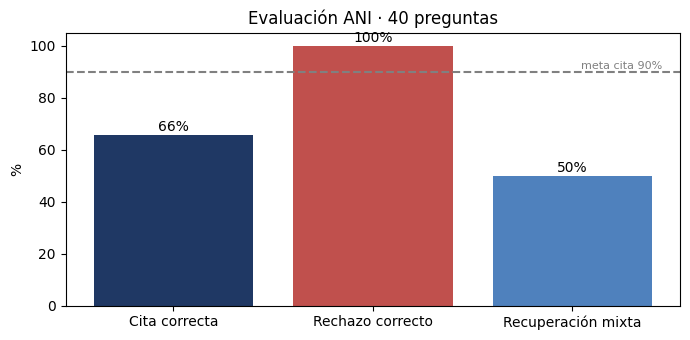


Fallos para revisar:
  #1 [cita] ¿Con qué nota se aprueba un ramo?
  #3 [cita, rechazo] ¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?
  #9 [cita] Mi hija tiene un diagnóstico médico pero no está en el PIE, ¿cómo pido que la evalúen distinto?
  #14 [cita] ¿Cuántas notas como mínimo tiene que tener mi hijo por semestre en un ramo?
  #19 [cita] ¿Pueden dejar a mi hijo sin recreo como castigo?
  #21 [cita] ¿Usar el celular en clases es falta grave?
  #22 [cita] Le aplicaron una medida a mi hijo y no estoy de acuerdo, ¿cuánto plazo tengo para apelar?
  #23 [cita] ¿Cuántos días máximo pueden suspender a mi hijo?
  #33 [cita, mixta] Mi hijo ha ido 150 de 180 días de clases. ¿Repite?
  #36 [cita] Mi hijo terminó Lenguaje con 3,95. ¿Se le sube a 4,0?
  #37 [cita, mixta] Si el reglamento del liceo dice algo distinto al decreto del ministerio, ¿cuál vale?
  #38 [mixta] ¿Cuánto puede pesar como máximo la prueba final en la nota del año?
  #39 [mixta] ¿Hasta cuándo tienen 

In [14]:
# ============================================================
# PASO 12 · Evaluación automática con el set de preguntas
# ============================================================
# Requisito: subir ANI_set_preguntas_prueba.xlsx a la carpeta ANI del Drive
# (como .xlsx, sin convertirlo a Google Sheets).
# Si se corta (Colab, 503, cuota), vuelve a ejecutar esta celda: retoma donde quedó.

!pip install -q openpyxl
import glob, os, re, time, json
import pandas as pd
import matplotlib.pyplot as plt

PAUSA = 6        # segundos entre preguntas (evita el error 429 de la cuota gratuita)
VERSION = "v1"   # cámbialo a "v2", "v3"... cada vez que mejores el agente, para comparar
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"

# ---------- 1. Cargar preguntas ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
if not candidatos:
    raise FileNotFoundError("No encontré ANI_set_preguntas_prueba.xlsx ni en la carpeta ANI ni en la del proyecto.")
archivo = sorted(candidatos)[-1]
df = pd.read_excel(archivo, sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
print(f"{len(df)} preguntas cargadas desde {os.path.basename(archivo)}")

# ---------- 2. Funciones de evaluación ----------
def paginas(texto):
    """'19-20' -> {19, 20}; '62 / 70' -> {62, 70}; '17.0' -> {17}"""
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def fuentes(respuesta):
    """Lista de (documento | ubicación, {páginas}), separando fuentes unidas con ';'"""
    out = []
    for linea in respuesta.splitlines():
        if "Fuente" not in linea:
            continue
        doc = ""
        for parte in linea.split(";"):
            if doc_clave(parte):
                doc = parte.split(",")[0]
            m = re.findall(r"p[áa]gs?\.?\s*([\d\s,\-–y]+)", parte)
            out.append((f"{doc} | {parte}", set().union(*map(paginas, m)) if m else set()))
    return out

def doc_clave(texto):
    claves = []
    if "Evaluaci" in texto: claves.append("Evaluaci")
    if "Convivencia" in texto: claves.append("Convivencia")
    if "Decreto" in texto: claves.append("Decreto")
    return claves

def cita_correcta(respuesta, doc_esp, pag_esp):
    """El documento interno esperado aparece citado y la página calza (tolerancia ±1)."""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pags_esp = paginas(pag_esp)
    for linea, pags in fuentes(respuesta):
        if any(c in linea for c in esperado):
            if not pags_esp:
                return True
            if any(abs(p - q) <= 1 for p in pags for q in pags_esp):
                return True
    return False

RECHAZO = "no está regulado"
def rechazo(respuesta):
    return RECHAZO in respuesta.lower()

# Artículos que existen en el corpus (para detectar artículos inventados)
ARTS_CORPUS = set()
for f in fragmentos:
    for t in (f["texto"], f["ubicacion"]):
        ARTS_CORPUS.update(re.findall(r"Art[íi]culo\s+(\d+)", t))
        ARTS_CORPUS.update(re.findall(r"Art\.\s*(\d+)", t))

def articulos_inventados(respuesta):
    citados = set(re.findall(r"Art(?:[íi]culo|\.)\s*(\d+)", respuesta))
    return sorted(citados - ARTS_CORPUS, key=int)

# ---------- 3. Correr las preguntas (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json")
resultados = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}

fallos_seguidos = 0
for _, fila in df.iterrows():
    clave = str(int(fila["n"]))
    if clave in resultados and resultados[clave]["modelo"]:
        continue
    if fallos_seguidos >= 3:
        print("⛔ 3 fallos seguidos: se acabó la cuota. Vuelve a ejecutar más tarde (retoma desde aquí).")
        break
    agente_eval = AgenteANI()                     # memoria limpia para cada pregunta
    inicio = time.time()
    texto, modelo = agente_eval.preguntar(fila["pregunta"])
    herramientas = [t["herramienta"] for t in traza]
    resultados[clave] = {"respuesta": texto, "modelo": modelo,
                         "segundos": round(time.time() - inicio, 1),
                         "herramientas": herramientas,
                         "consultas": [{"herramienta": t["herramienta"], "consulta": t["consulta"],
                                        "dominio": t.get("dominio")} for t in traza if "consulta" in t]}
    json.dump(resultados, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{clave:>2}/{len(df)}] {resultados[clave]['segundos']:>5}s · {', '.join(herramientas) or 'sin herramientas'}")
    fallos_seguidos = 0 if modelo else fallos_seguidos + 1
    time.sleep(PAUSA)

# ---------- 4. Calcular métricas ----------
pendientes = [str(int(n)) for n in df["n"] if not resultados.get(str(int(n)), {}).get("modelo")]
if pendientes:
    raise RuntimeError(f"Faltan {len(pendientes)} preguntas ({', '.join(pendientes)}). "
                       "Vuelve a ejecutar esta celda cuando se recupere la cuota.")
filas = []
for _, fila in df.iterrows():
    r = resultados[str(int(fila["n"]))]
    resp = r["respuesta"]
    debe_rechazar = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    es_mixta = str(fila["mixta"]).strip().lower() in ("sí", "si")
    rechazo_ok = rechazo(resp) if debe_rechazar else not rechazo(resp)
    cita_ok = None if debe_rechazar else cita_correcta(resp, fila["doc_esperado"], fila["pagina"])
    mixta_ok = None
    if es_mixta:
        cito = " ".join(l for l, _ in fuentes(resp))
        mixta_ok = ("buscar_norma_interna" in r["herramientas"] and "buscar_norma_externa" in r["herramientas"]
                    and "Decreto" in cito and ("Evaluaci" in cito or "Convivencia" in cito))
    filas.append({**fila.to_dict(), "respuesta_ANI": resp, "modelo": r["modelo"], "segundos": r["segundos"],
                  "herramientas": ", ".join(r["herramientas"]), "cita_correcta": cita_ok,
                  "rechazo_correcto": rechazo_ok, "mixta_recuperada": mixta_ok,
                  "articulos_inventados": ", ".join(articulos_inventados(resp)),
                  "¿Contenido correcto? (manual)": ""})
res = pd.DataFrame(filas)

normales = res[res["cita_correcta"].notna()]
rech = res[res["rechazar"].astype(str).str.lower().isin(["sí", "si"])]
mixtas = res[res["mixta_recuperada"].notna()]
falsos_rechazos = (~res.loc[~res.index.isin(rech.index), "rechazo_correcto"].astype(bool)).sum()
n_inventados = sum(len(a.split(", ")) for a in res["articulos_inventados"] if a)

metricas = pd.DataFrame([
    ["Cita correcta", normales["cita_correcta"].astype(bool).mean() * 100, "≥ 90%", f"{normales['cita_correcta'].astype(bool).sum()}/{len(normales)}"],
    ["Rechazo correcto", rech["rechazo_correcto"].astype(bool).mean() * 100, "100%", f"{rech['rechazo_correcto'].astype(bool).sum()}/{len(rech)}"],
    ["Recuperación mixta", mixtas["mixta_recuperada"].astype(bool).mean() * 100, "—", f"{mixtas['mixta_recuperada'].astype(bool).sum()}/{len(mixtas)}"],
    ["Artículos inventados", n_inventados, "0", "artículos"],
    ["Falsos rechazos", falsos_rechazos, "0", "preguntas"],
    ["Tiempo promedio (s)", res["segundos"].mean(), "—", "segundos"],
], columns=["Métrica", "Valor", "Meta", "Detalle"])
metricas["Valor"] = metricas["Valor"].round(1)
print("\n", metricas.to_string(index=False))

# ---------- 5. Guardar Excel + gráfico para el informe ----------
xlsx = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
nombres = ["Cita correcta", "Rechazo correcto", "Recuperación mixta"]
valores = metricas.set_index("Métrica").loc[nombres, "Valor"]
barras = ax.bar(nombres, valores, color=["#1F3864", "#C0504D", "#4F81BD"])
ax.axhline(90, ls="--", color="gray"); ax.text(2.45, 91, "meta cita 90%", ha="right", fontsize=8, color="gray")
ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(f"Evaluación ANI · {len(res)} preguntas")
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.savefig(os.path.join(CARPETA, f"ANI_metricas{SUFIJO}.png"), dpi=200); plt.show()

print("\nFallos para revisar:")
for _, f in res.iterrows():
    problemas = []
    if f["cita_correcta"] is not None and pd.notna(f["cita_correcta"]) and not f["cita_correcta"]: problemas.append("cita")
    if not f["rechazo_correcto"]: problemas.append("rechazo")
    if f["mixta_recuperada"] is not None and pd.notna(f["mixta_recuperada"]) and not f["mixta_recuperada"]: problemas.append("mixta")
    if f["articulos_inventados"]: problemas.append(f"art. inventado {f['articulos_inventados']}")
    if problemas:
        print(f"  #{int(f['n'])} [{', '.join(problemas)}] {f['pregunta']}")
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_metricas{SUFIJO}.png")

40 preguntas · respuestas de ANI versión v1

=== Evaluación IL1.4 · versión v1 ===
                    Métrica  Valor Umbral ¿Cumple?
Exactitud vs referencia (%)   65.0     80        ❌
   Fidelidad promedio (/10)    7.6      8        ❌
  Relevancia promedio (/10)    8.9      8        ✅
      Context Precision (%)   30.8     50        ❌
         Context Recall (%)   62.5     80        ❌
  Hit@k página esperada (%)   75.0     80        ❌
       Rechazo correcto (%)  100.0    100        ✅
       Latencia mediana (s)    8.1      —        —

Veredicto: 2/7 criterios cumplidos → NO FUNCIONA AÚN

Diagnóstico por componente (qué falla):
diagnostico
OK                                                 21
falla de RECUPERACIÓN (el dato no llegó)           12
falla de GENERACIÓN (alucina)                       4
falla de GENERACIÓN (tenía el dato y no lo usó)     2
rechazo mal resuelto                                1

Preguntas con problemas:
  # 1 [falla de RECUPERACIÓN (el dato no llegó)] ¿Con q

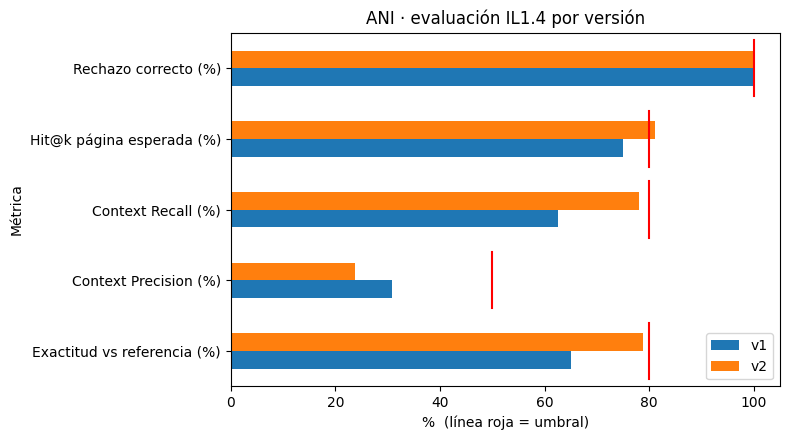


Guardado en Drive: ANI_evaluacion_IL14.xlsx y ANI_evaluacion_IL14.png


In [15]:
# ============================================================
# PASO 13 · Evaluación con los criterios de RA1 · IL1.4
#   Recuperación: Context Precision, Context Recall, Hit@k (página esperada)
#   Generación:   Faithfulness (fidelidad), Answer Relevancy, Exactitud vs referencia
#   Juez: un LLM distinto al que responde (LLM-as-a-judge, temperatura 0)
# ============================================================
# Requisitos: haber corrido el Paso 12 (usa sus respuestas guardadas; NO vuelve a preguntarle a ANI).
# Gasta 1 consulta por pregunta (40 en total). Si se corta, vuelve a ejecutar: retoma donde quedó.

import os, re, json, time, glob
import pandas as pd
import matplotlib.pyplot as plt

VERSION = globals().get("VERSION", "v1")      # misma versión que el Paso 12
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"
JUECES = ["gemini-flash-latest", "gemini-3.5-flash", "gemini-3.1-flash-lite"]  # distinto al que responde, si hay cuota
PAUSA = 4
MAX_CHARS = 4000                              # por fragmento, para no reventar el contexto del juez

# Umbrales para decir "funciona" (definidos por el equipo; el curso no fija valores)
UMBRALES = {
    "Exactitud vs referencia (%)": 80,
    "Fidelidad promedio (/10)": 8,
    "Relevancia promedio (/10)": 8,
    "Context Precision (%)": 50,
    "Context Recall (%)": 80,
    "Hit@k página esperada (%)": 80,
    "Rechazo correcto (%)": 100,
}

# ---------- 1. Cargar preguntas y respuestas del Paso 12 ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
df = pd.read_excel(sorted(candidatos)[-1], sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
resp = json.load(open(os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json"), encoding="utf-8"))
print(f"{len(df)} preguntas · respuestas de ANI versión {VERSION}")

def paginas(texto):
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def doc_clave(texto):
    return [c for c in ("Evaluaci", "Convivencia", "Decreto") if c in str(texto)]

SINONIMO = {"evaluación": "evaluacion", "convivencia": "convivencia"}

# ---------- 2. Reconstruir el contexto que recuperó el agente ----------
# Los embeddings son locales (e5-small): re-buscar no gasta cuota de Gemini.
def contexto(fila, r):
    frs = []
    consultas = r.get("consultas")
    if consultas:                                   # Paso 12 nuevo: consultas reales del agente
        for c in consultas:
            if c["herramienta"] == "buscar_norma_interna":
                frs += buscar(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
            elif c["herramienta"] == "buscar_norma_externa":
                frs += buscar(c["consulta"], "externa", k=3)
    else:                                           # resultados antiguos: aproxima con la pregunta
        dom = SINONIMO.get(fila["dominio"])
        if "buscar_norma_interna" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "interna", k=4, dominio=dom)
        if "buscar_norma_externa" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "externa", k=3)
    vistos, unicos = set(), []
    for f in frs:
        clave = (f["documento"], f["ubicacion"], f["paginas"], f["texto"][:50])
        if clave not in vistos:
            vistos.add(clave); unicos.append(f)
    return unicos

def hit_pagina(frs, doc_esp, pag_esp):
    """¿Algún fragmento recuperado es del documento esperado y cubre la página (±1)?"""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pe = paginas(pag_esp)
    for f in frs:
        if any(c in f["documento"] for c in esperado):
            if not pe or any(abs(p - q) <= 1 for p in paginas(f["paginas"]) for q in pe):
                return True
    return False

# ---------- 3. El juez ----------
PROMPT_JUEZ = """Eres un evaluador estricto de un sistema RAG que responde dudas de apoderados sobre reglamentos escolares.

PREGUNTA: {pregunta}

RESPUESTA DE REFERENCIA (correcta): {referencia}

FRAGMENTOS RECUPERADOS:
{fragmentos}

RESPUESTA DEL SISTEMA:
{respuesta}

Evalúa y responde SOLO con un JSON con estas claves:
- "fidelidad": entero 1-10. ¿Todo lo que afirma la respuesta está respaldado por los FRAGMENTOS? (1-3 inventa o contradice, 4-6 parcialmente, 7-10 totalmente). Si la respuesta solo dice que no está regulado, evalúa si eso es coherente con los fragmentos.
- "relevancia": entero 1-10. ¿Responde de forma directa y útil lo que preguntó el apoderado?
- "exactitud": "CORRECTO", "PARCIAL" o "INCORRECTO" comparando con la RESPUESTA DE REFERENCIA (no exijas coincidencia literal; un plazo, número o responsable distinto es INCORRECTO).
- "fragmentos_relevantes": lista con los números de los fragmentos útiles para responder (ej: [1, 3]); [] si ninguno.
- "contexto_suficiente": true si los fragmentos contienen la información de la referencia, false si no.
- "comentario": una frase con el problema principal, o "" si no hay."""

def juzgar(fila, r, frs):
    fragmentos = "\n\n".join(f"[F{i+1}] {f['documento']} | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto'][:MAX_CHARS]}"
                             for i, f in enumerate(frs)) or "(ninguno: el agente no buscó)"
    prompt = PROMPT_JUEZ.format(pregunta=fila["pregunta"], referencia=fila["resp_esperada"],
                                fragmentos=fragmentos, respuesta=r["respuesta"])
    cfg = types.GenerateContentConfig(temperature=0, response_mime_type="application/json")
    for modelo in JUECES:
        for intento in range(3):
            try:
                out = client.models.generate_content(model=modelo, contents=prompt, config=cfg)
                datos = json.loads(re.sub(r"```json|```", "", out.text).strip())
                datos["juez"] = modelo
                return datos
            except Exception as e:
                error = str(e)
                if "PerDay" in error:
                    break
                if any(x in error for x in ("429", "503", "UNAVAILABLE")):
                    time.sleep(10 * (intento + 1)); continue
                if isinstance(e, json.JSONDecodeError):
                    continue
                raise
    return None

# ---------- 4. Correr el juez (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_juez_IL14{SUFIJO}.json")
juicios = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}
fallos = 0
for _, fila in df.iterrows():
    k = str(int(fila["n"]))
    if k in juicios:
        continue
    if fallos >= 3:
        print("⛔ El juez se quedó sin cuota. Vuelve a ejecutar más tarde (retoma desde aquí)."); break
    r = resp[k]
    frs = contexto(fila, r)
    j = juzgar(fila, r, frs)
    if j is None:
        fallos += 1; continue
    fallos = 0
    j["n_fragmentos"] = len(frs)
    j["hit_pagina"] = hit_pagina(frs, fila["doc_esperado"], fila["pagina"])
    juicios[k] = j
    json.dump(juicios, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{k:>2}/{len(df)}] {j['exactitud']:<10} fid {j['fidelidad']:>2} · rel {j['relevancia']:>2} · {j['juez']}")
    time.sleep(PAUSA)

faltan = [str(int(n)) for n in df["n"] if str(int(n)) not in juicios]
if faltan:
    raise RuntimeError(f"Faltan {len(faltan)} juicios ({', '.join(faltan)}). Vuelve a ejecutar cuando haya cuota.")

# ---------- 5. Métricas IL1.4 ----------
filas = []
for _, fila in df.iterrows():
    k = str(int(fila["n"])); j = juicios[k]; r = resp[k]
    rechazo = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    nfr = j["n_fragmentos"]
    prec = (len(set(j["fragmentos_relevantes"]) & set(range(1, nfr + 1))) / nfr) if (nfr and not rechazo) else None
    exact = {"CORRECTO": 1, "PARCIAL": 0.5, "INCORRECTO": 0}.get(str(j["exactitud"]).upper(), 0)
    # Diagnóstico IL1.4: ¿falla el recuperador o el generador?
    if exact == 1 and j["fidelidad"] >= 7:
        diag = "OK"
    elif rechazo:
        diag = "rechazo mal resuelto"
    elif not j["contexto_suficiente"]:
        diag = "falla de RECUPERACIÓN (el dato no llegó)"
    elif j["fidelidad"] < 7:
        diag = "falla de GENERACIÓN (alucina)"
    else:
        diag = "falla de GENERACIÓN (tenía el dato y no lo usó)"
    filas.append({"n": int(fila["n"]), "pregunta": fila["pregunta"], "capacidad": fila["capacidad"],
                  "respuesta_esperada": fila["resp_esperada"], "respuesta_ANI": r["respuesta"],
                  "exactitud": j["exactitud"], "exactitud_num": exact, "fidelidad": j["fidelidad"],
                  "relevancia": j["relevancia"], "context_precision": prec,
                  "context_recall": None if rechazo else bool(j["contexto_suficiente"]),
                  "hit_pagina": None if rechazo else bool(j["hit_pagina"]),
                  "rechazo_ok": ("no está regulado" in r["respuesta"].lower()) if rechazo else None,
                  "segundos": r["segundos"], "diagnostico": diag, "comentario_juez": j.get("comentario", ""),
                  "juez": j["juez"]})
res = pd.DataFrame(filas)
nr = res[res["context_recall"].notna()]

valores = {
    "Exactitud vs referencia (%)": res["exactitud_num"].mean() * 100,
    "Fidelidad promedio (/10)": res["fidelidad"].mean(),
    "Relevancia promedio (/10)": res["relevancia"].mean(),
    "Context Precision (%)": nr["context_precision"].astype(float).mean() * 100,
    "Context Recall (%)": nr["context_recall"].astype(bool).mean() * 100,
    "Hit@k página esperada (%)": nr["hit_pagina"].astype(bool).mean() * 100,
    "Rechazo correcto (%)": res["rechazo_ok"].dropna().astype(bool).mean() * 100,
}
metricas = pd.DataFrame([{"Métrica": m, "Valor": round(v, 1), "Umbral": UMBRALES[m],
                          "¿Cumple?": "✅" if v >= UMBRALES[m] else "❌"} for m, v in valores.items()])
metricas.loc[len(metricas)] = ["Latencia mediana (s)", round(res["segundos"].median(), 1), "—", "—"]
print(f"\n=== Evaluación IL1.4 · versión {VERSION} ===")
print(metricas.to_string(index=False))

cumple = (metricas["¿Cumple?"] == "✅").sum(); total = len(UMBRALES)
print(f"\nVeredicto: {cumple}/{total} criterios cumplidos →",
      "FUNCIONA" if cumple == total else "FUNCIONA PARCIALMENTE" if cumple >= total / 2 else "NO FUNCIONA AÚN")

print("\nDiagnóstico por componente (qué falla):")
print(res["diagnostico"].value_counts().to_string())
print("\nPreguntas con problemas:")
for _, f in res[res["diagnostico"] != "OK"].iterrows():
    print(f"  #{f['n']:>2} [{f['diagnostico']}] {f['pregunta']}\n       → {f['comentario_juez']}")

# ---------- 6. Guardar + comparar versiones ----------
xlsx = os.path.join(CARPETA, f"ANI_evaluacion_IL14{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

comparacion = {}
for archivo in sorted(glob.glob(os.path.join(CARPETA, "ANI_evaluacion_IL14*.xlsx"))):
    m = re.search(r"IL14_?(v\d+)?\.xlsx$", archivo)
    ver = (m.group(1) if m and m.group(1) else "v1")
    tabla = pd.read_excel(archivo, sheet_name="Métricas").set_index("Métrica")["Valor"]
    comparacion[ver] = tabla
comp = pd.DataFrame(comparacion).loc[list(UMBRALES)]
if comp.shape[1] > 1:
    print("\nComparación entre versiones:")
    print(comp.to_string())

pct = [m for m in UMBRALES if "%" in m]
ax = comp.loc[pct].plot(kind="barh", figsize=(8, 4.5))
for i, m in enumerate(pct):
    ax.plot([UMBRALES[m]] * 2, [i - 0.4, i + 0.4], color="red", lw=1.5)
ax.set_xlim(0, 105); ax.set_xlabel("%  (línea roja = umbral)")
ax.set_title("ANI · evaluación IL1.4 por versión"); plt.tight_layout()
plt.savefig(os.path.join(CARPETA, "ANI_evaluacion_IL14.png"), dpi=200); plt.show()
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_evaluacion_IL14.png")

In [16]:
# ============================================================
# PASO 14 · Mejora de la recuperación (versión v2)
#   Diagnóstico del Paso 13: 12 de 19 fallos fueron de RECUPERACIÓN (el dato no llegó al modelo).
#   Cambios:
#   1. Fragmentos más chicos (800 caracteres en vez de 1.500) → cada dato queda menos "diluido".
#   2. Búsqueda HÍBRIDA: semántica (embeddings) + léxica (BM25, palabras exactas como "10 días hábiles"),
#      combinadas con Reciprocal Rank Fusion (RRF).
#   3. Más fragmentos por búsqueda (6) y cuota del otro reglamento (por si el agente elige mal el dominio).
#   4. Prompt: re-buscar con sinónimos antes de rechazar y citar solo lo que aparece en los fragmentos.
# Tiempo: unos 5 minutos (recalcula los embeddings).
# ============================================================
!pip install -q rank_bm25
import json, os, re, unicodedata
from rank_bm25 import BM25Okapi

# ---------- 0. Se restaura la función limpiar del Paso 6 ----------
#   (en los Pasos 11 y 11C el botón "Nueva conversación" se llamaba igual y la tapó)
def limpiar(linea):
    linea = linea.replace("\u00a0", " ").strip()
    if not linea or any(p.search(linea) for p in RUIDO):
        return None
    return linea

# ---------- 1. Fragmentos más chicos ----------
fragmentos = []
for archivo, nombre, tipo, anio, saltar in DOCUMENTOS:
    secs = segmentar(os.path.join(CARPETA, archivo), nombre, tipo, anio, saltar)
    frs = [f for s in secs for f in fragmentar(s, max_chars=800, solape=150)]
    print(f"{nombre}: {len(frs)} fragmentos")
    fragmentos += frs
for i, f in enumerate(fragmentos):
    f["id"] = f"v2_{i:04d}"
POR_ID = {f["id"]: f for f in fragmentos}
with open(os.path.join(CARPETA, "fragmentos_v2.json"), "w", encoding="utf-8") as fh:
    json.dump(fragmentos, fh, ensure_ascii=False, indent=1)
print("Total v2:", len(fragmentos))

# ---------- 2. Índice semántico (reconstruye las 2 colecciones de ChromaDB) ----------
for tipo in ["interna", "externa"]:
    nombre = f"norma_{tipo}"
    try:
        cliente_db.delete_collection(nombre)
    except Exception:
        pass
    col = cliente_db.create_collection(nombre, metadata={"hnsw:space": "cosine"})
    frs = [f for f in fragmentos if f["tipo"] == tipo]
    col.add(ids=[f["id"] for f in frs],
            documents=[f["texto"] for f in frs],
            embeddings=emb_pasajes([f"{f['documento']} | {f['ubicacion']}\n{f['texto']}" for f in frs]),
            metadatas=[{k: f[k] for k in ("documento", "tipo", "anio", "ubicacion", "paginas", "parte")} for f in frs])
    colecciones[tipo] = col
    print(f"Colección {nombre}: {col.count()} fragmentos")

# ---------- 3. Índice léxico (BM25) ----------
STOPWORDS = set("""a al algo ante antes como con cual cuales cuando de del desde donde el ella ellas ellos en entre
era es esa ese eso esta este esto estos fue ha hay la las le les lo los mas me mi mis muy no nos o para pero por que se
si sin sobre su sus te tiene tu un una uno unos y ya""".split())

def normalizar(texto):
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")      # quita tildes
    palabras = []
    for w in re.findall(r"[a-z0-9]+", texto):
        if w in STOPWORDS:
            continue
        if len(w) > 4 and w.endswith("es"):   w = w[:-2]                       # plurales simples
        elif len(w) > 3 and w.endswith("s"):  w = w[:-1]
        palabras.append(w)
    return palabras

INDICE = {}
for tipo in ["interna", "externa"]:
    frs = [f for f in fragmentos if f["tipo"] == tipo]
    INDICE[tipo] = {"frs": frs, "bm25": BM25Okapi([normalizar(f["ubicacion"] + " " + f["texto"]) for f in frs])}

# ---------- 4. Búsqueda híbrida (reemplaza la función buscar de los pasos anteriores) ----------
K_INTERNA, K_EXTERNA, CUOTA_OTRO = 6, 4, 2

def _hibrida(consulta, tipo, k, dominio):
    idx = INDICE[tipo]
    pool = [i for i, f in enumerate(idx["frs"]) if dominio is None or f["documento"] == DOMINIOS[dominio]]
    # a) semántica
    filtro = {"documento": DOMINIOS[dominio]} if dominio else None
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=min(30, len(pool)), where=filtro)
    ids_sem = r["ids"][0]
    sims = {i: 1 - d for i, d in zip(r["ids"][0], r["distances"][0])}
    # b) léxica
    puntajes = idx["bm25"].get_scores(normalizar(consulta))
    ids_lex = [idx["frs"][i]["id"] for i in sorted(pool, key=lambda i: -puntajes[i])[:30] if puntajes[i] > 0]
    # c) fusión RRF
    rrf = {}
    for lista in (ids_sem, ids_lex):
        for rango, fid in enumerate(lista):
            rrf[fid] = rrf.get(fid, 0) + 1 / (60 + rango + 1)
    # d) se aseguran los 2 mejores de cada método y el resto se completa por RRF
    mejores = list(dict.fromkeys(ids_lex[:2] + ids_sem[:2]))[:k]
    mejores += [fid for fid in sorted(rrf, key=lambda f: -rrf[f]) if fid not in mejores][:k - len(mejores)]
    return [{**POR_ID[fid], "similitud": round(sims.get(fid, 0.0), 3), "rrf": round(rrf[fid], 4)} for fid in mejores]

def buscar(consulta, tipo="interna", k=6, dominio=None):
    if tipo == "interna":
        k = max(k, K_INTERNA)
        if dominio in DOMINIOS:                      # 4 del dominio elegido + 2 del otro reglamento
            otro = [d for d in DOMINIOS if d != dominio][0]
            return _hibrida(consulta, tipo, k - CUOTA_OTRO, dominio) + _hibrida(consulta, tipo, CUOTA_OTRO, otro)
        return _hibrida(consulta, tipo, k, None)
    return _hibrida(consulta, tipo, max(k, K_EXTERNA), None)

# ---------- 5. Prompt: re-buscar antes de rechazar y citar solo lo recuperado ----------
REGLAS_V2 = """
8. Si los fragmentos no responden la pregunta, vuelve a buscar al menos una vez con sinónimos del reglamento
   (nota → calificación; prueba → evaluación; falta → inasistencia; castigo → medida o sanción; profe → docente)
   o en el otro dominio. Solo después de eso responde "No está regulado en los documentos disponibles."
9. Cita EXACTAMENTE el documento, la ubicación y las páginas del encabezado [F#] del fragmento que respalda cada dato.
   Nunca cites artículos, secciones o páginas que no aparezcan en los fragmentos.
10. Aunque conozcas la respuesta por conocimiento general (por ejemplo, trámites de JUNAEB o del MINEDUC), si no está en los fragmentos, no la entregues."""
if "8. Si los fragmentos no responden" not in PROMPT_AGENTE:
    PROMPT_AGENTE = PROMPT_AGENTE.replace("\n\nREGLAS", REGLAS_V2 + "\n\nREGLAS", 1)
CONFIG_AGENTE = types.GenerateContentConfig(system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

# ---------- 6. Prueba rápida de recuperación (sin gastar cuota de Gemini) ----------
pruebas = [
    ("plazo docente entregar resultados de evaluaciones días hábiles", "evaluacion", "no exceda los 10"),
    ("calificación mínima de aprobación", "evaluacion", "mínima de aprobación"),
    ("atrasos citación al apoderado", "convivencia", "quinto (5) atraso"),
    ("plazo para justificar inasistencia certificado médico", "evaluacion", "5 días hábiles"),   # dominio "equivocado" a propósito
    ("aproximación de la calificación final", "evaluacion", "aproximación"),
]
print("\nPrueba de recuperación v2:")
for consulta, dominio, clave in pruebas:
    frs = buscar(consulta, "interna", dominio=dominio)
    pos = next((i + 1 for i, f in enumerate(frs) if clave.lower() in f["texto"].lower()), None)
    print(f"  {'✅' if pos else '❌'} {consulta[:55]:<55} → {'posición ' + str(pos) if pos else 'no encontrado'}")
print("\nListo. Ahora ejecuta el Paso 12 con VERSION = \"v2\" y luego el Paso 13 para comparar.")

Reglamento de Evaluación y Promoción 2026: 164 fragmentos
Reglamento Interno de Convivencia Escolar 2026: 975 fragmentos
Decreto 67/2018 (MINEDUC): 51 fragmentos
Total v2: 1190


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Colección norma_interna: 1139 fragmentos


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Colección norma_externa: 51 fragmentos

Prueba de recuperación v2:
  ✅ plazo docente entregar resultados de evaluaciones días  → posición 1
  ✅ calificación mínima de aprobación                       → posición 1
  ✅ atrasos citación al apoderado                           → posición 1
  ✅ plazo para justificar inasistencia certificado médico   → posición 6
  ✅ aproximación de la calificación final                   → posición 1

Listo. Ahora ejecuta el Paso 12 con VERSION = "v2" y luego el Paso 13 para comparar.


40 preguntas cargadas desde ANI_set_preguntas_prueba.xlsx

              Métrica  Valor  Meta   Detalle
       Cita correcta   78.1 ≥ 90%     25/32
    Rechazo correcto  100.0  100%       8/8
  Recuperación mixta   37.5     —       3/8
Artículos inventados    0.0     0 artículos
     Falsos rechazos    0.0     0 preguntas
 Tiempo promedio (s)   10.0     —  segundos


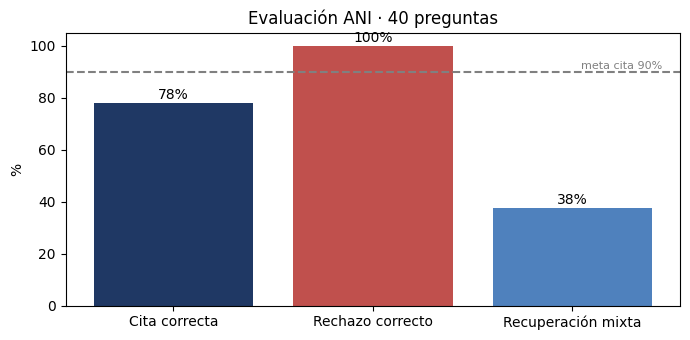


Fallos para revisar:
  #3 [cita] ¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?
  #14 [cita] ¿Cuántas notas como mínimo tiene que tener mi hijo por semestre en un ramo?
  #19 [cita] ¿Pueden dejar a mi hijo sin recreo como castigo?
  #21 [cita] ¿Usar el celular en clases es falta grave?
  #22 [cita] Le aplicaron una medida a mi hijo y no estoy de acuerdo, ¿cuánto plazo tengo para apelar?
  #24 [cita] ¿Quién decide si expulsan a un alumno?
  #33 [cita, mixta] Mi hijo ha ido 150 de 180 días de clases. ¿Repite?
  #36 [mixta] Mi hijo terminó Lenguaje con 3,95. ¿Se le sube a 4,0?
  #37 [mixta] Si el reglamento del liceo dice algo distinto al decreto del ministerio, ¿cuál vale?
  #38 [mixta] ¿Cuánto puede pesar como máximo la prueba final en la nota del año?
  #40 [mixta] No estoy de acuerdo con la decisión de promoción y el reglamento no dice qué hacer, ¿a quién recurro?

Guardado en Drive: ANI_resultados_evaluacion_v2.xlsx y ANI_metricas_v2.png


In [17]:
# ============================================================
# PASO 15 · Re-evaluación del agente mejorado (v2) con el set completo
#   Mismo código del Paso 12, pero con VERSION = "v2": responde TODAS las preguntas
#   del Excel con la búsqueda híbrida del Paso 14 y guarda en archivos _v2 (no pisa los de v1).
# Si se corta (Colab, 503, cuota), vuelve a ejecutar esta celda: retoma donde quedó.
# ============================================================

!pip install -q openpyxl
import glob, os, re, time, json
import pandas as pd
import matplotlib.pyplot as plt

PAUSA = 6        # segundos entre preguntas (evita el error 429 de la cuota gratuita)
VERSION = "v2"   # versión mejorada (Paso 14)
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"

# ---------- 1. Cargar preguntas ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
if not candidatos:
    raise FileNotFoundError("No encontré ANI_set_preguntas_prueba.xlsx ni en la carpeta ANI ni en la del proyecto.")
archivo = sorted(candidatos)[-1]
df = pd.read_excel(archivo, sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
print(f"{len(df)} preguntas cargadas desde {os.path.basename(archivo)}")

# ---------- 2. Funciones de evaluación ----------
def paginas(texto):
    """'19-20' -> {19, 20}; '62 / 70' -> {62, 70}; '17.0' -> {17}"""
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def fuentes(respuesta):
    """Lista de (documento | ubicación, {páginas}), separando fuentes unidas con ';'"""
    out = []
    for linea in respuesta.splitlines():
        if "Fuente" not in linea:
            continue
        doc = ""
        for parte in linea.split(";"):
            if doc_clave(parte):
                doc = parte.split(",")[0]
            m = re.findall(r"p[áa]gs?\.?\s*([\d\s,\-–y]+)", parte)
            out.append((f"{doc} | {parte}", set().union(*map(paginas, m)) if m else set()))
    return out

def doc_clave(texto):
    claves = []
    if "Evaluaci" in texto: claves.append("Evaluaci")
    if "Convivencia" in texto: claves.append("Convivencia")
    if "Decreto" in texto: claves.append("Decreto")
    return claves

def cita_correcta(respuesta, doc_esp, pag_esp):
    """El documento interno esperado aparece citado y la página calza (tolerancia ±1)."""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pags_esp = paginas(pag_esp)
    for linea, pags in fuentes(respuesta):
        if any(c in linea for c in esperado):
            if not pags_esp:
                return True
            if any(abs(p - q) <= 1 for p in pags for q in pags_esp):
                return True
    return False

RECHAZO = "no está regulado"
def rechazo(respuesta):
    return RECHAZO in respuesta.lower()

# Artículos que existen en el corpus (para detectar artículos inventados)
ARTS_CORPUS = set()
for f in fragmentos:
    for t in (f["texto"], f["ubicacion"]):
        ARTS_CORPUS.update(re.findall(r"Art[íi]culo\s+(\d+)", t))
        ARTS_CORPUS.update(re.findall(r"Art\.\s*(\d+)", t))

def articulos_inventados(respuesta):
    citados = set(re.findall(r"Art(?:[íi]culo|\.)\s*(\d+)", respuesta))
    return sorted(citados - ARTS_CORPUS, key=int)

# ---------- 3. Correr las preguntas (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json")
resultados = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}

fallos_seguidos = 0
for _, fila in df.iterrows():
    clave = str(int(fila["n"]))
    if clave in resultados and resultados[clave]["modelo"]:
        continue
    if fallos_seguidos >= 3:
        print("⛔ 3 fallos seguidos: se acabó la cuota. Vuelve a ejecutar más tarde (retoma desde aquí).")
        break
    agente_eval = AgenteANI()                     # memoria limpia para cada pregunta
    inicio = time.time()
    texto, modelo = agente_eval.preguntar(fila["pregunta"])
    herramientas = [t["herramienta"] for t in traza]
    resultados[clave] = {"respuesta": texto, "modelo": modelo,
                         "segundos": round(time.time() - inicio, 1),
                         "herramientas": herramientas,
                         "consultas": [{"herramienta": t["herramienta"], "consulta": t["consulta"],
                                        "dominio": t.get("dominio")} for t in traza if "consulta" in t]}
    json.dump(resultados, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{clave:>2}/{len(df)}] {resultados[clave]['segundos']:>5}s · {', '.join(herramientas) or 'sin herramientas'}")
    fallos_seguidos = 0 if modelo else fallos_seguidos + 1
    time.sleep(PAUSA)

# ---------- 4. Calcular métricas ----------
pendientes = [str(int(n)) for n in df["n"] if not resultados.get(str(int(n)), {}).get("modelo")]
if pendientes:
    raise RuntimeError(f"Faltan {len(pendientes)} preguntas ({', '.join(pendientes)}). "
                       "Vuelve a ejecutar esta celda cuando se recupere la cuota.")
filas = []
for _, fila in df.iterrows():
    r = resultados[str(int(fila["n"]))]
    resp = r["respuesta"]
    debe_rechazar = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    es_mixta = str(fila["mixta"]).strip().lower() in ("sí", "si")
    rechazo_ok = rechazo(resp) if debe_rechazar else not rechazo(resp)
    cita_ok = None if debe_rechazar else cita_correcta(resp, fila["doc_esperado"], fila["pagina"])
    mixta_ok = None
    if es_mixta:
        cito = " ".join(l for l, _ in fuentes(resp))
        mixta_ok = ("buscar_norma_interna" in r["herramientas"] and "buscar_norma_externa" in r["herramientas"]
                    and "Decreto" in cito and ("Evaluaci" in cito or "Convivencia" in cito))
    filas.append({**fila.to_dict(), "respuesta_ANI": resp, "modelo": r["modelo"], "segundos": r["segundos"],
                  "herramientas": ", ".join(r["herramientas"]), "cita_correcta": cita_ok,
                  "rechazo_correcto": rechazo_ok, "mixta_recuperada": mixta_ok,
                  "articulos_inventados": ", ".join(articulos_inventados(resp)),
                  "¿Contenido correcto? (manual)": ""})
res = pd.DataFrame(filas)

normales = res[res["cita_correcta"].notna()]
rech = res[res["rechazar"].astype(str).str.lower().isin(["sí", "si"])]
mixtas = res[res["mixta_recuperada"].notna()]
falsos_rechazos = (~res.loc[~res.index.isin(rech.index), "rechazo_correcto"].astype(bool)).sum()
n_inventados = sum(len(a.split(", ")) for a in res["articulos_inventados"] if a)

metricas = pd.DataFrame([
    ["Cita correcta", normales["cita_correcta"].astype(bool).mean() * 100, "≥ 90%", f"{normales['cita_correcta'].astype(bool).sum()}/{len(normales)}"],
    ["Rechazo correcto", rech["rechazo_correcto"].astype(bool).mean() * 100, "100%", f"{rech['rechazo_correcto'].astype(bool).sum()}/{len(rech)}"],
    ["Recuperación mixta", mixtas["mixta_recuperada"].astype(bool).mean() * 100, "—", f"{mixtas['mixta_recuperada'].astype(bool).sum()}/{len(mixtas)}"],
    ["Artículos inventados", n_inventados, "0", "artículos"],
    ["Falsos rechazos", falsos_rechazos, "0", "preguntas"],
    ["Tiempo promedio (s)", res["segundos"].mean(), "—", "segundos"],
], columns=["Métrica", "Valor", "Meta", "Detalle"])
metricas["Valor"] = metricas["Valor"].round(1)
print("\n", metricas.to_string(index=False))

# ---------- 5. Guardar Excel + gráfico para el informe ----------
xlsx = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
nombres = ["Cita correcta", "Rechazo correcto", "Recuperación mixta"]
valores = metricas.set_index("Métrica").loc[nombres, "Valor"]
barras = ax.bar(nombres, valores, color=["#1F3864", "#C0504D", "#4F81BD"])
ax.axhline(90, ls="--", color="gray"); ax.text(2.45, 91, "meta cita 90%", ha="right", fontsize=8, color="gray")
ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(f"Evaluación ANI · {len(res)} preguntas")
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.savefig(os.path.join(CARPETA, f"ANI_metricas{SUFIJO}.png"), dpi=200); plt.show()

print("\nFallos para revisar:")
for _, f in res.iterrows():
    problemas = []
    if f["cita_correcta"] is not None and pd.notna(f["cita_correcta"]) and not f["cita_correcta"]: problemas.append("cita")
    if not f["rechazo_correcto"]: problemas.append("rechazo")
    if f["mixta_recuperada"] is not None and pd.notna(f["mixta_recuperada"]) and not f["mixta_recuperada"]: problemas.append("mixta")
    if f["articulos_inventados"]: problemas.append(f"art. inventado {f['articulos_inventados']}")
    if problemas:
        print(f"  #{int(f['n'])} [{', '.join(problemas)}] {f['pregunta']}")
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_metricas{SUFIJO}.png")

40 preguntas · respuestas de ANI versión v2

=== Evaluación IL1.4 · versión v2 ===
                    Métrica  Valor Umbral ¿Cumple?
Exactitud vs referencia (%)   78.8     80        ❌
   Fidelidad promedio (/10)    9.6      8        ✅
  Relevancia promedio (/10)    9.3      8        ✅
      Context Precision (%)   23.7     50        ❌
         Context Recall (%)   78.1     80        ❌
  Hit@k página esperada (%)   81.2     80        ✅
       Rechazo correcto (%)  100.0    100        ✅
       Latencia mediana (s)    5.6      —        —

Veredicto: 4/7 criterios cumplidos → FUNCIONA PARCIALMENTE

Diagnóstico por componente (qué falla):
diagnostico
OK                                                 28
falla de RECUPERACIÓN (el dato no llegó)            7
falla de GENERACIÓN (tenía el dato y no lo usó)     4
rechazo mal resuelto                                1

Preguntas con problemas:
  # 3 [falla de RECUPERACIÓN (el dato no llegó)] ¿En cuánto tiempo el profe tiene que entregar las nota

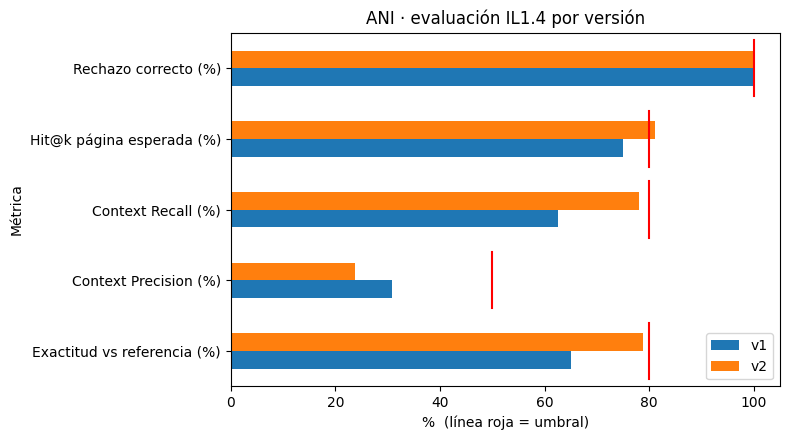


Guardado en Drive: ANI_evaluacion_IL14_v2.xlsx y ANI_evaluacion_IL14.png


In [18]:
# ============================================================
# PASO 16 · Juez IL1.4 sobre la versión v2 + comparación v1 vs v2
#   Mismo código del Paso 13, pero con VERSION = "v2".
#   El Paso 15 solo revisa el FORMATO de la cita; aquí un LLM juez revisa si el CONTENIDO es correcto
#   y dice si cada fallo es de RECUPERACIÓN o de GENERACIÓN.
# Gasta 1 consulta por pregunta (40). Si se corta, vuelve a ejecutar: retoma donde quedó.
# ============================================================

import os, re, json, time, glob
import pandas as pd
import matplotlib.pyplot as plt

VERSION = "v2"                              # versión mejorada (Paso 14)
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"
JUECES = ["gemini-flash-latest", "gemini-3.5-flash", "gemini-3.1-flash-lite"]  # distinto al que responde, si hay cuota
PAUSA = 4
MAX_CHARS = 4000                              # por fragmento, para no reventar el contexto del juez

# Umbrales para decir "funciona" (definidos por el equipo; el curso no fija valores)
UMBRALES = {
    "Exactitud vs referencia (%)": 80,
    "Fidelidad promedio (/10)": 8,
    "Relevancia promedio (/10)": 8,
    "Context Precision (%)": 50,
    "Context Recall (%)": 80,
    "Hit@k página esperada (%)": 80,
    "Rechazo correcto (%)": 100,
}

# ---------- 1. Cargar preguntas y respuestas del Paso 15 ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
df = pd.read_excel(sorted(candidatos)[-1], sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
resp = json.load(open(os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json"), encoding="utf-8"))
print(f"{len(df)} preguntas · respuestas de ANI versión {VERSION}")

def paginas(texto):
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def doc_clave(texto):
    return [c for c in ("Evaluaci", "Convivencia", "Decreto") if c in str(texto)]

SINONIMO = {"evaluación": "evaluacion", "convivencia": "convivencia"}

# ---------- 2. Reconstruir el contexto que recuperó el agente ----------
# Los embeddings son locales (e5-small): re-buscar no gasta cuota de Gemini.
def contexto(fila, r):
    frs = []
    consultas = r.get("consultas")
    if consultas:                                   # consultas reales del agente
        for c in consultas:
            if c["herramienta"] == "buscar_norma_interna":
                frs += buscar(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
            elif c["herramienta"] == "buscar_norma_externa":
                frs += buscar(c["consulta"], "externa", k=3)
    else:                                           # resultados antiguos: aproxima con la pregunta
        dom = SINONIMO.get(fila["dominio"])
        if "buscar_norma_interna" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "interna", k=4, dominio=dom)
        if "buscar_norma_externa" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "externa", k=3)
    vistos, unicos = set(), []
    for f in frs:
        clave = (f["documento"], f["ubicacion"], f["paginas"], f["texto"][:50])
        if clave not in vistos:
            vistos.add(clave); unicos.append(f)
    return unicos

def hit_pagina(frs, doc_esp, pag_esp):
    """¿Algún fragmento recuperado es del documento esperado y cubre la página (±1)?"""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pe = paginas(pag_esp)
    for f in frs:
        if any(c in f["documento"] for c in esperado):
            if not pe or any(abs(p - q) <= 1 for p in paginas(f["paginas"]) for q in pe):
                return True
    return False

# ---------- 3. El juez ----------
PROMPT_JUEZ = """Eres un evaluador estricto de un sistema RAG que responde dudas de apoderados sobre reglamentos escolares.

PREGUNTA: {pregunta}

RESPUESTA DE REFERENCIA (correcta): {referencia}

FRAGMENTOS RECUPERADOS:
{fragmentos}

RESPUESTA DEL SISTEMA:
{respuesta}

Evalúa y responde SOLO con un JSON con estas claves:
- "fidelidad": entero 1-10. ¿Todo lo que afirma la respuesta está respaldado por los FRAGMENTOS? (1-3 inventa o contradice, 4-6 parcialmente, 7-10 totalmente). Si la respuesta solo dice que no está regulado, evalúa si eso es coherente con los fragmentos.
- "relevancia": entero 1-10. ¿Responde de forma directa y útil lo que preguntó el apoderado?
- "exactitud": "CORRECTO", "PARCIAL" o "INCORRECTO" comparando con la RESPUESTA DE REFERENCIA (no exijas coincidencia literal; un plazo, número o responsable distinto es INCORRECTO).
- "fragmentos_relevantes": lista con los números de los fragmentos útiles para responder (ej: [1, 3]); [] si ninguno.
- "contexto_suficiente": true si los fragmentos contienen la información de la referencia, false si no.
- "comentario": una frase con el problema principal, o "" si no hay."""

def juzgar(fila, r, frs):
    fragmentos = "\n\n".join(f"[F{i+1}] {f['documento']} | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto'][:MAX_CHARS]}"
                             for i, f in enumerate(frs)) or "(ninguno: el agente no buscó)"
    prompt = PROMPT_JUEZ.format(pregunta=fila["pregunta"], referencia=fila["resp_esperada"],
                                fragmentos=fragmentos, respuesta=r["respuesta"])
    cfg = types.GenerateContentConfig(temperature=0, response_mime_type="application/json")
    for modelo in JUECES:
        for intento in range(3):
            try:
                out = client.models.generate_content(model=modelo, contents=prompt, config=cfg)
                datos = json.loads(re.sub(r"```json|```", "", out.text).strip())
                datos["juez"] = modelo
                return datos
            except Exception as e:
                error = str(e)
                if "PerDay" in error:
                    break
                if any(x in error for x in ("429", "503", "UNAVAILABLE")):
                    time.sleep(10 * (intento + 1)); continue
                if isinstance(e, json.JSONDecodeError):
                    continue
                raise
    return None

# ---------- 4. Correr el juez (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_juez_IL14{SUFIJO}.json")
juicios = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}
fallos = 0
for _, fila in df.iterrows():
    k = str(int(fila["n"]))
    if k in juicios:
        continue
    if fallos >= 3:
        print("⛔ El juez se quedó sin cuota. Vuelve a ejecutar más tarde (retoma desde aquí)."); break
    r = resp[k]
    frs = contexto(fila, r)
    j = juzgar(fila, r, frs)
    if j is None:
        fallos += 1; continue
    fallos = 0
    j["n_fragmentos"] = len(frs)
    j["hit_pagina"] = hit_pagina(frs, fila["doc_esperado"], fila["pagina"])
    juicios[k] = j
    json.dump(juicios, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{k:>2}/{len(df)}] {j['exactitud']:<10} fid {j['fidelidad']:>2} · rel {j['relevancia']:>2} · {j['juez']}")
    time.sleep(PAUSA)

faltan = [str(int(n)) for n in df["n"] if str(int(n)) not in juicios]
if faltan:
    raise RuntimeError(f"Faltan {len(faltan)} juicios ({', '.join(faltan)}). Vuelve a ejecutar cuando haya cuota.")

# ---------- 5. Métricas IL1.4 ----------
filas = []
for _, fila in df.iterrows():
    k = str(int(fila["n"])); j = juicios[k]; r = resp[k]
    rechazo = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    nfr = j["n_fragmentos"]
    prec = (len(set(j["fragmentos_relevantes"]) & set(range(1, nfr + 1))) / nfr) if (nfr and not rechazo) else None
    exact = {"CORRECTO": 1, "PARCIAL": 0.5, "INCORRECTO": 0}.get(str(j["exactitud"]).upper(), 0)
    # Diagnóstico IL1.4: ¿falla el recuperador o el generador?
    if exact == 1 and j["fidelidad"] >= 7:
        diag = "OK"
    elif rechazo:
        diag = "rechazo mal resuelto"
    elif not j["contexto_suficiente"]:
        diag = "falla de RECUPERACIÓN (el dato no llegó)"
    elif j["fidelidad"] < 7:
        diag = "falla de GENERACIÓN (alucina)"
    else:
        diag = "falla de GENERACIÓN (tenía el dato y no lo usó)"
    filas.append({"n": int(fila["n"]), "pregunta": fila["pregunta"], "capacidad": fila["capacidad"],
                  "respuesta_esperada": fila["resp_esperada"], "respuesta_ANI": r["respuesta"],
                  "exactitud": j["exactitud"], "exactitud_num": exact, "fidelidad": j["fidelidad"],
                  "relevancia": j["relevancia"], "context_precision": prec,
                  "context_recall": None if rechazo else bool(j["contexto_suficiente"]),
                  "hit_pagina": None if rechazo else bool(j["hit_pagina"]),
                  "rechazo_ok": ("no está regulado" in r["respuesta"].lower()) if rechazo else None,
                  "segundos": r["segundos"], "diagnostico": diag, "comentario_juez": j.get("comentario", ""),
                  "juez": j["juez"]})
res = pd.DataFrame(filas)
nr = res[res["context_recall"].notna()]

valores = {
    "Exactitud vs referencia (%)": res["exactitud_num"].mean() * 100,
    "Fidelidad promedio (/10)": res["fidelidad"].mean(),
    "Relevancia promedio (/10)": res["relevancia"].mean(),
    "Context Precision (%)": nr["context_precision"].astype(float).mean() * 100,
    "Context Recall (%)": nr["context_recall"].astype(bool).mean() * 100,
    "Hit@k página esperada (%)": nr["hit_pagina"].astype(bool).mean() * 100,
    "Rechazo correcto (%)": res["rechazo_ok"].dropna().astype(bool).mean() * 100,
}
metricas = pd.DataFrame([{"Métrica": m, "Valor": round(v, 1), "Umbral": UMBRALES[m],
                          "¿Cumple?": "✅" if v >= UMBRALES[m] else "❌"} for m, v in valores.items()])
metricas.loc[len(metricas)] = ["Latencia mediana (s)", round(res["segundos"].median(), 1), "—", "—"]
print(f"\n=== Evaluación IL1.4 · versión {VERSION} ===")
print(metricas.to_string(index=False))

cumple = (metricas["¿Cumple?"] == "✅").sum(); total = len(UMBRALES)
print(f"\nVeredicto: {cumple}/{total} criterios cumplidos →",
      "FUNCIONA" if cumple == total else "FUNCIONA PARCIALMENTE" if cumple >= total / 2 else "NO FUNCIONA AÚN")

print("\nDiagnóstico por componente (qué falla):")
print(res["diagnostico"].value_counts().to_string())
print("\nPreguntas con problemas:")
for _, f in res[res["diagnostico"] != "OK"].iterrows():
    print(f"  #{f['n']:>2} [{f['diagnostico']}] {f['pregunta']}\n       → {f['comentario_juez']}")
    print("       ANI dijo: " + f["respuesta_ANI"].replace("\n", " ")[:300] + "…")

# ---------- 6. Guardar + comparar versiones ----------
xlsx = os.path.join(CARPETA, f"ANI_evaluacion_IL14{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

comparacion = {}
for archivo in sorted(glob.glob(os.path.join(CARPETA, "ANI_evaluacion_IL14*.xlsx"))):
    m = re.search(r"IL14_?(v\d+)?\.xlsx$", archivo)
    ver = (m.group(1) if m and m.group(1) else "v1")
    tabla = pd.read_excel(archivo, sheet_name="Métricas").set_index("Métrica")["Valor"]
    comparacion[ver] = tabla
comp = pd.DataFrame(comparacion).loc[list(UMBRALES)]
if comp.shape[1] > 1:
    print("\nComparación entre versiones:")
    print(comp.to_string())

pct = [m for m in UMBRALES if "%" in m]
ax = comp.loc[pct].plot(kind="barh", figsize=(8, 4.5))
for i, m in enumerate(pct):
    ax.plot([UMBRALES[m]] * 2, [i - 0.4, i + 0.4], color="red", lw=1.5)
ax.set_xlim(0, 105); ax.set_xlabel("%  (línea roja = umbral)")
ax.set_title("ANI · evaluación IL1.4 por versión"); plt.tight_layout()
plt.savefig(os.path.join(CARPETA, "ANI_evaluacion_IL14.png"), dpi=200); plt.show()
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_evaluacion_IL14.png")

In [19]:
# ============================================================
# PASO 17 · Mejora v3: multi-consulta + reglas de respuesta completa
#   Diagnóstico del Paso 16 (v2): 7 fallos de RECUPERACIÓN y 4 de GENERACIÓN (respuestas incompletas).
#   Cambios:
#   1. Multi-consulta: cada búsqueda combina la consulta reformulada por el agente con la pregunta
#      ORIGINAL del apoderado (4 rankings fusionados con RRF). Mismo número de fragmentos → no agrega ruido.
#      Motivo: en v2 el agente a veces reformulaba la pregunta y el dato no llegaba (ej: #3, plazo de 10 días).
#   2. Prompt: respuesta completa (todos los plazos/condiciones), ambas fuentes en promoción/asistencia/
#      certificados, y rechazo sin recomendar cosas externas.
#   3. Prueba sin gastar cuota: con las consultas REALES que hizo el agente en v2, ¿ahora llega el dato?
# ============================================================
import json, os

# ---------- 1. Guardar la pregunta original del apoderado en cada turno ----------
PREGUNTA_ACTUAL = {"texto": ""}
if not hasattr(AgenteANI, "_preguntar_base"):              # evita envolverla dos veces si re-ejecutas
    AgenteANI._preguntar_base = AgenteANI.preguntar

def preguntar_v3(self, mensaje):
    PREGUNTA_ACTUAL["texto"] = mensaje
    return AgenteANI._preguntar_base(self, mensaje)

AgenteANI.preguntar = preguntar_v3

# ---------- 2. Búsqueda híbrida multi-consulta ----------
if "buscar_v2" not in globals():
    buscar_v2 = buscar                                       # se guarda la v2 para comparar

def _rankings(consulta, tipo, dominio, n=30):
    idx = INDICE[tipo]
    pool = [i for i, f in enumerate(idx["frs"]) if dominio is None or f["documento"] == DOMINIOS[dominio]]
    filtro = {"documento": DOMINIOS[dominio]} if dominio else None
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=min(n, len(pool)), where=filtro)
    sims = {i: 1 - d for i, d in zip(r["ids"][0], r["distances"][0])}
    puntajes = idx["bm25"].get_scores(normalizar(consulta))
    lex = [idx["frs"][i]["id"] for i in sorted(pool, key=lambda i: -puntajes[i])[:n] if puntajes[i] > 0]
    return r["ids"][0], lex, sims

def _hibrida_multi(consultas, tipo, k, dominio):
    sem, lex, sims = [], [], {}
    for c in consultas:
        s, l, si = _rankings(c, tipo, dominio)
        sem.append(s); lex.append(l)
        for fid, v in si.items():
            sims[fid] = max(sims.get(fid, 0.0), v)
    rrf = {}
    for lista in sem + lex:
        for rango, fid in enumerate(lista):
            rrf[fid] = rrf.get(fid, 0) + 1 / (60 + rango + 1)
    # se asegura el mejor resultado de cada consulta y de cada método (alternados); el resto se completa por RRF
    orden = [lex[0], sem[-1], sem[0], lex[-1]] if len(consultas) > 1 else [lex[0], sem[0]]
    garantizados = [l[0] for l in orden if l]
    mejores = list(dict.fromkeys(garantizados))[:k]
    mejores += [fid for fid in sorted(rrf, key=lambda f: -rrf[f]) if fid not in mejores][:k - len(mejores)]
    return [{**POR_ID[fid], "similitud": round(sims.get(fid, 0.0), 3), "rrf": round(rrf[fid], 4)} for fid in mejores]

def buscar(consulta, tipo="interna", k=6, dominio=None):
    original = PREGUNTA_ACTUAL["texto"].strip()
    consultas = [consulta] + ([original] if original and original.lower() != consulta.lower() else [])
    if tipo == "interna":
        k = max(k, K_INTERNA)
        if dominio in DOMINIOS:                              # 4 del dominio elegido + 2 del otro reglamento
            otro = [d for d in DOMINIOS if d != dominio][0]
            return (_hibrida_multi(consultas, tipo, k - CUOTA_OTRO, dominio) +
                    _hibrida_multi(consultas, tipo, CUOTA_OTRO, otro))
        return _hibrida_multi(consultas, tipo, k, None)
    return _hibrida_multi(consultas, tipo, max(k, K_EXTERNA), None)

# ---------- 3. Prompt: respuesta completa, ambas fuentes y rechazo limpio ----------
REGLAS_V3 = """
11. Responde COMPLETO: incluye todos los plazos, requisitos, condiciones, responsables y excepciones que aparezcan
    en los fragmentos relacionados con la pregunta. Si hay plazos o reglas distintas según el tipo de caso
    (por ejemplo, falta leve o grave vs. expulsión), menciona cada uno.
12. Si la pregunta trata de promoción, repitencia, asistencia, calificación final o certificados, busca SIEMPRE en
    ambas fuentes (buscar_norma_interna y buscar_norma_externa) y cita ambas.
13. Si la consulta está fuera del alcance de los reglamentos, responde solo "No está regulado en los documentos
    disponibles." y sugiere consultar en el liceo. No recomiendes servicios, instituciones ni trámites externos."""
if "11. Responde COMPLETO" not in PROMPT_AGENTE:
    PROMPT_AGENTE = PROMPT_AGENTE.replace("\n\nREGLAS", REGLAS_V3 + "\n\nREGLAS", 1)
CONFIG_AGENTE = types.GenerateContentConfig(system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)
print("Reglas 11-13 en el prompt:", "11. Responde COMPLETO" in PROMPT_AGENTE)

# ---------- 4. Prueba sin gastar cuota: consultas reales del agente en v2 ----------
#   (pregunta, texto que debe llegar al agente)
CASOS = {
    3:  "no exceda los 10",            # plazo de entrega de notas
    14: "al menos 2 notas",            # mínimo de notas por semestre
    17: "quinto (5) atraso",           # citación por atrasos
    22: "3 días hábiles desde la",     # plazo de apelación (faltas)
    13: "no podrá ser retenido",       # certificado anual (Decreto 67)
    33: "igual o superior al 85%",     # asistencia mínima
}
v2 = json.load(open(os.path.join(CARPETA, "ANI_resultados_evaluacion_v2.json"), encoding="utf-8"))
preguntas_set = dict(zip(df["n"].astype(int), df["pregunta"]))

def llega(n, version):
    PREGUNTA_ACTUAL["texto"] = preguntas_set[n] if version == "v3" else ""
    funcion = buscar if version == "v3" else buscar_v2
    for c in v2[str(n)]["consultas"]:
        if c["herramienta"] == "buscar_norma_interna":
            frs = funcion(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
        else:
            frs = funcion(c["consulta"], "externa", k=3)
        if any(CASOS[n].lower() in f["texto"].lower() for f in frs):
            return True
    return False

print("\n¿Llega el dato al agente? (mismas consultas que hizo el agente en v2)")
print(f"  {'#':>3}  {'v2':^4} {'v3':^4}  pregunta")
for n in CASOS:
    a, b = llega(n, "v2"), llega(n, "v3")
    print(f"  {n:>3}  {'✅' if a else '❌':^4} {'✅' if b else '❌':^4}  {preguntas_set[n][:70]}")
    for c in v2[str(n)]["consultas"]:
        print(f"              ↳ el agente buscó: {c['consulta'][:80]}  ({c.get('dominio') or c['herramienta'][-7:]})")
PREGUNTA_ACTUAL["texto"] = ""
print("\nSi una fila sigue ❌, depende de que el agente busque en la fuente correcta (reglas 11-12 del prompt).")
print("Siguiente: Paso 18 (re-evaluación v3).")

Reglas 11-13 en el prompt: True

¿Llega el dato al agente? (mismas consultas que hizo el agente en v2)
    #   v2   v3   pregunta
    3   ❌    ❌    ¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?
              ↳ el agente buscó: plazo entrega calificaciones resultados evaluaciones docentes  (evaluacion)
   14   ❌    ✅    ¿Cuántas notas como mínimo tiene que tener mi hijo por semestre en un 
              ↳ el agente buscó: número mínimo de calificaciones por semestre por asignatura  (evaluacion)
   17   ❌    ❌    ¿Cuántos atrasos puede tener antes de que me citen?
              ↳ el agente buscó: atrasos citación apoderado procedimiento  (convivencia)
   22   ❌    ✅    Le aplicaron una medida a mi hijo y no estoy de acuerdo, ¿cuánto plazo
              ↳ el agente buscó: apelacion medida disciplinaria sancion plazo debido proceso reclamo apoderado  (convivencia)
              ↳ el agente buscó: "Protocolo de normas de convivencia escolar y faltas" apelación plazo

In [20]:
# ============================================================
# PASO 18 · Re-ranking: ¿qué buscador recupera mejor? (sin gastar cuota de Gemini)
#   Hallazgo del Paso 17: en #3, #17 y #33 el fragmento correcto queda 3° o más abajo en el ranking,
#   y como el agente recibe pocos fragmentos, no alcanza a llegar.
#   Se comparan 4 buscadores con las consultas REALES que hizo el agente en v2, en TODAS las preguntas:
#     v2          → híbrida del Paso 14
#     v3          → multi-consulta del Paso 17
#     v3 RRF      → multi-consulta, ranking solo por fusión RRF (premia lo que aparece arriba en varias listas)
#     v3 reranker → multi-consulta + un segundo modelo (cross-encoder) que relee los 20 mejores
#                   candidatos junto a la pregunta y los reordena
#   Al final queda activo el que gane. Tiempo: 2-4 minutos (descarga el reranker la primera vez).
# ============================================================
import time
import pandas as pd
from sentence_transformers import CrossEncoder

RERANKER = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1", max_length=384)   # multilingüe (incluye español)
N_CANDIDATOS = 20
_cache_ce = {}

if "buscar_v3" not in globals():
    buscar_v3 = buscar                                       # se guarda la v3 del Paso 17

def _candidatos(consultas, tipo, dominio):
    rrf, sims = {}, {}
    for c in consultas:
        sem, lex, si = _rankings(c, tipo, dominio)
        for fid, v in si.items():
            sims[fid] = max(sims.get(fid, 0.0), v)
        for lista in (sem, lex):
            for rango, fid in enumerate(lista):
                rrf[fid] = rrf.get(fid, 0) + 1 / (60 + rango + 1)
    return sorted(rrf, key=lambda f: -rrf[f]), sims, rrf

def _reordenar(consultas, candidatos):
    pendientes = [(q, fid) for fid in candidatos for q in consultas if (q, fid) not in _cache_ce]
    if pendientes:
        pares = [(q, f"{POR_ID[fid]['ubicacion']}. {POR_ID[fid]['texto']}") for q, fid in pendientes]
        for clave, p in zip(pendientes, RERANKER.predict(pares, batch_size=32)):
            _cache_ce[clave] = float(p)
    puntaje = {fid: max(_cache_ce[(q, fid)] for q in consultas) for fid in candidatos}
    return sorted(candidatos, key=lambda f: -puntaje[f])

def _hibrida_v4(consultas, tipo, k, dominio, rerank):
    orden, sims, rrf = _candidatos(consultas, tipo, dominio)
    mejores = _reordenar(consultas, orden[:N_CANDIDATOS])[:k] if rerank else orden[:k]
    return [{**POR_ID[fid], "similitud": round(sims.get(fid, 0.0), 3), "rrf": round(rrf[fid], 4)} for fid in mejores]

def hacer_buscar(rerank):
    def _buscar(consulta, tipo="interna", k=6, dominio=None):
        original = PREGUNTA_ACTUAL["texto"].strip()
        consultas = [consulta] + ([original] if original and original.lower() != consulta.lower() else [])
        if tipo == "interna":
            k = max(k, K_INTERNA)
            if dominio in DOMINIOS:
                otro = [d for d in DOMINIOS if d != dominio][0]
                return (_hibrida_v4(consultas, tipo, k - CUOTA_OTRO, dominio, rerank) +
                        _hibrida_v4(consultas, tipo, CUOTA_OTRO, otro, rerank))
            return _hibrida_v4(consultas, tipo, k, None, rerank)
        return _hibrida_v4(consultas, tipo, max(k, K_EXTERNA), None, rerank)
    return _buscar

VARIANTES = {"v2": buscar_v2, "v3": buscar_v3,
             "v3 RRF": hacer_buscar(False), "v3 reranker": hacer_buscar(True)}

# ---------- Comparación con las consultas reales del agente (v2) ----------
def hit_pagina(frs, doc_esp, pag_esp):
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pe = paginas(pag_esp)
    return any(any(c in f["documento"] for c in esperado) and
               (not pe or any(abs(p - q) <= 1 for p in paginas(f["paginas"]) for q in pe)) for f in frs)

def recuperar(funcion, n, version):
    PREGUNTA_ACTUAL["texto"] = preguntas_set[n] if version != "v2" else ""
    frs = []
    for c in v2[str(n)]["consultas"]:
        if c["herramienta"] == "buscar_norma_interna":
            frs += funcion(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
        else:
            frs += funcion(c["consulta"], "externa", k=3)
    return frs

con_respuesta = df[~df["rechazar"].astype(str).str.strip().str.lower().isin(["sí", "si"])]
tabla = []
for nombre, funcion in VARIANTES.items():
    inicio = time.time()
    hits = casos = 0
    for _, fila in con_respuesta.iterrows():
        n = int(fila["n"])
        frs = recuperar(funcion, n, nombre)
        hits += hit_pagina(frs, fila["doc_esperado"], fila["pagina"])
        if n in CASOS:
            casos += any(CASOS[n].lower() in f["texto"].lower() for f in frs)
    tabla.append({"Buscador": nombre,
                  "Hit@k página esperada": f"{hits}/{len(con_respuesta)} ({100 * hits / len(con_respuesta):.0f}%)",
                  "Casos difíciles (Paso 17)": f"{casos}/{len(CASOS)}",
                  "_orden": (hits, casos), "Tiempo (s)": round(time.time() - inicio, 1)})
    print(f"  {nombre} listo")
PREGUNTA_ACTUAL["texto"] = ""

tabla = pd.DataFrame(tabla)
print("\n", tabla.drop(columns="_orden").to_string(index=False))

# ---------- Queda activo el mejor ----------
i_mejor = max(range(len(tabla)), key=lambda i: tabla["_orden"][i])     # en empate gana el más simple
mejor = tabla["Buscador"][i_mejor]
buscar = VARIANTES[mejor]
print(f"\n✅ Buscador activo: {mejor}")
print("Siguiente: Paso 19 (re-evaluación completa v3 con Gemini).")

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  v2 listo
  v3 listo
  v3 RRF listo
  v3 reranker listo

    Buscador Hit@k página esperada Casos difíciles (Paso 17)  Tiempo (s)
         v2           26/32 (81%)                       0/6         7.8
         v3           30/32 (94%)                       3/6        21.6
     v3 RRF           26/32 (81%)                       5/6        23.8
v3 reranker           29/32 (91%)                       5/6       878.1

✅ Buscador activo: v3
Siguiente: Paso 19 (re-evaluación completa v3 con Gemini).


Buscador activo: v3 reranker
40 preguntas cargadas desde ANI_set_preguntas_prueba.xlsx
⏱️ 84.3 s con gemini-3.1-flash-lite · búsquedas: True
[36/40]  84.3s · buscar_norma_interna, buscar_norma_externa
⏱️ 9.2 s con gemini-3.1-flash-lite · búsquedas: True
[37/40]   9.2s · buscar_norma_externa
⏱️ 23.5 s con gemini-3.1-flash-lite · búsquedas: True
[38/40]  23.5s · buscar_norma_interna, buscar_norma_externa
⏱️ 24.3 s con gemini-3.1-flash-lite · búsquedas: True
[39/40]  24.3s · buscar_norma_interna, buscar_norma_externa
⏱️ 77.3 s con gemini-3.1-flash-lite · búsquedas: True
[40/40]  77.3s · buscar_norma_interna, buscar_norma_externa

              Métrica  Valor  Meta   Detalle
       Cita correcta   81.2 ≥ 90%     26/32
    Rechazo correcto  100.0  100%       8/8
  Recuperación mixta   62.5     —       5/8
Artículos inventados    0.0     0 artículos
     Falsos rechazos    0.0     0 preguntas
 Tiempo promedio (s)   18.1     —  segundos


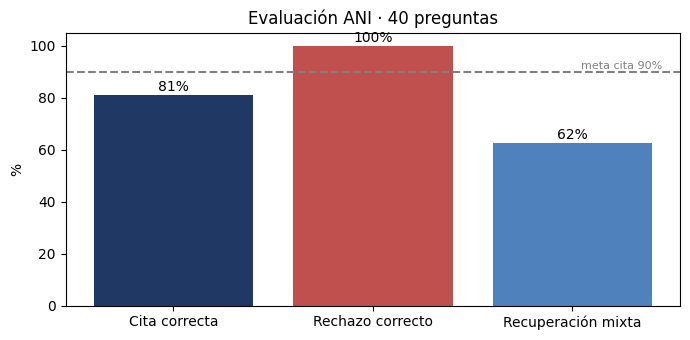


Fallos para revisar:
  #17 [cita] ¿Cuántos atrasos puede tener antes de que me citen?
  #19 [cita] ¿Pueden dejar a mi hijo sin recreo como castigo?
  #22 [cita] Le aplicaron una medida a mi hijo y no estoy de acuerdo, ¿cuánto plazo tengo para apelar?
  #23 [cita] ¿Cuántos días máximo pueden suspender a mi hijo?
  #24 [cita] ¿Quién decide si expulsan a un alumno?
  #33 [mixta] Mi hijo ha ido 150 de 180 días de clases. ¿Repite?
  #36 [mixta] Mi hijo terminó Lenguaje con 3,95. ¿Se le sube a 4,0?
  #37 [cita, mixta] Si el reglamento del liceo dice algo distinto al decreto del ministerio, ¿cuál vale?

Guardado en Drive: ANI_resultados_evaluacion_v3.xlsx y ANI_metricas_v3.png


In [21]:
# ============================================================
# PASO 19 · Re-evaluación completa v3 (multi-consulta + reranker + reglas 11-13)
#   Decisión del Paso 18: se usa el buscador con reranker. Recupera 5 de 6 casos difíciles
#   (v3 sin reranker: 3 de 6) con Hit@k similar (91% vs 94%). Costo: más latencia por búsqueda.
#   Mismo código del Paso 15, pero con VERSION = "v3" (guarda en archivos _v3, no pisa v1 ni v2).
# Si se corta (Colab, 503, cuota), vuelve a ejecutar esta celda: retoma donde quedó.
# ============================================================
buscar = VARIANTES["v3 reranker"]
print("Buscador activo: v3 reranker")

!pip install -q openpyxl
import glob, os, re, time, json
import pandas as pd
import matplotlib.pyplot as plt

PAUSA = 6        # segundos entre preguntas (evita el error 429 de la cuota gratuita)
VERSION = "v3"   # multi-consulta + reranker + reglas 11-13 (Pasos 17-18)
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"

# ---------- 1. Cargar preguntas ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
if not candidatos:
    raise FileNotFoundError("No encontré ANI_set_preguntas_prueba.xlsx ni en la carpeta ANI ni en la del proyecto.")
archivo = sorted(candidatos)[-1]
df = pd.read_excel(archivo, sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
print(f"{len(df)} preguntas cargadas desde {os.path.basename(archivo)}")

# ---------- 2. Funciones de evaluación ----------
def paginas(texto):
    """'19-20' -> {19, 20}; '62 / 70' -> {62, 70}; '17.0' -> {17}"""
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def fuentes(respuesta):
    """Lista de (documento | ubicación, {páginas}), separando fuentes unidas con ';'"""
    out = []
    for linea in respuesta.splitlines():
        if "Fuente" not in linea:
            continue
        doc = ""
        for parte in linea.split(";"):
            if doc_clave(parte):
                doc = parte.split(",")[0]
            m = re.findall(r"p[áa]gs?\.?\s*([\d\s,\-–y]+)", parte)
            out.append((f"{doc} | {parte}", set().union(*map(paginas, m)) if m else set()))
    return out

def doc_clave(texto):
    claves = []
    if "Evaluaci" in texto: claves.append("Evaluaci")
    if "Convivencia" in texto: claves.append("Convivencia")
    if "Decreto" in texto: claves.append("Decreto")
    return claves

def cita_correcta(respuesta, doc_esp, pag_esp):
    """El documento interno esperado aparece citado y la página calza (tolerancia ±1)."""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pags_esp = paginas(pag_esp)
    for linea, pags in fuentes(respuesta):
        if any(c in linea for c in esperado):
            if not pags_esp:
                return True
            if any(abs(p - q) <= 1 for p in pags for q in pags_esp):
                return True
    return False

RECHAZO = "no está regulado"
def rechazo(respuesta):
    return RECHAZO in respuesta.lower()

# Artículos que existen en el corpus (para detectar artículos inventados)
ARTS_CORPUS = set()
for f in fragmentos:
    for t in (f["texto"], f["ubicacion"]):
        ARTS_CORPUS.update(re.findall(r"Art[íi]culo\s+(\d+)", t))
        ARTS_CORPUS.update(re.findall(r"Art\.\s*(\d+)", t))

def articulos_inventados(respuesta):
    citados = set(re.findall(r"Art(?:[íi]culo|\.)\s*(\d+)", respuesta))
    return sorted(citados - ARTS_CORPUS, key=int)

# ---------- 3. Correr las preguntas (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json")
resultados = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}

fallos_seguidos = 0
for _, fila in df.iterrows():
    clave = str(int(fila["n"]))
    if clave in resultados and resultados[clave]["modelo"]:
        continue
    if fallos_seguidos >= 3:
        print("⛔ 3 fallos seguidos: se acabó la cuota. Vuelve a ejecutar más tarde (retoma desde aquí).")
        break
    agente_eval = AgenteANI()                     # memoria limpia para cada pregunta
    inicio = time.time()
    texto, modelo = agente_eval.preguntar(fila["pregunta"])
    herramientas = [t["herramienta"] for t in traza]
    resultados[clave] = {"respuesta": texto, "modelo": modelo,
                         "segundos": round(time.time() - inicio, 1),
                         "herramientas": herramientas,
                         "consultas": [{"herramienta": t["herramienta"], "consulta": t["consulta"],
                                        "dominio": t.get("dominio")} for t in traza if "consulta" in t]}
    json.dump(resultados, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{clave:>2}/{len(df)}] {resultados[clave]['segundos']:>5}s · {', '.join(herramientas) or 'sin herramientas'}")
    fallos_seguidos = 0 if modelo else fallos_seguidos + 1
    time.sleep(PAUSA)

# ---------- 4. Calcular métricas ----------
pendientes = [str(int(n)) for n in df["n"] if not resultados.get(str(int(n)), {}).get("modelo")]
if pendientes:
    raise RuntimeError(f"Faltan {len(pendientes)} preguntas ({', '.join(pendientes)}). "
                       "Vuelve a ejecutar esta celda cuando se recupere la cuota.")
filas = []
for _, fila in df.iterrows():
    r = resultados[str(int(fila["n"]))]
    resp = r["respuesta"]
    debe_rechazar = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    es_mixta = str(fila["mixta"]).strip().lower() in ("sí", "si")
    rechazo_ok = rechazo(resp) if debe_rechazar else not rechazo(resp)
    cita_ok = None if debe_rechazar else cita_correcta(resp, fila["doc_esperado"], fila["pagina"])
    mixta_ok = None
    if es_mixta:
        cito = " ".join(l for l, _ in fuentes(resp))
        mixta_ok = ("buscar_norma_interna" in r["herramientas"] and "buscar_norma_externa" in r["herramientas"]
                    and "Decreto" in cito and ("Evaluaci" in cito or "Convivencia" in cito))
    filas.append({**fila.to_dict(), "respuesta_ANI": resp, "modelo": r["modelo"], "segundos": r["segundos"],
                  "herramientas": ", ".join(r["herramientas"]), "cita_correcta": cita_ok,
                  "rechazo_correcto": rechazo_ok, "mixta_recuperada": mixta_ok,
                  "articulos_inventados": ", ".join(articulos_inventados(resp)),
                  "¿Contenido correcto? (manual)": ""})
res = pd.DataFrame(filas)

normales = res[res["cita_correcta"].notna()]
rech = res[res["rechazar"].astype(str).str.lower().isin(["sí", "si"])]
mixtas = res[res["mixta_recuperada"].notna()]
falsos_rechazos = (~res.loc[~res.index.isin(rech.index), "rechazo_correcto"].astype(bool)).sum()
n_inventados = sum(len(a.split(", ")) for a in res["articulos_inventados"] if a)

metricas = pd.DataFrame([
    ["Cita correcta", normales["cita_correcta"].astype(bool).mean() * 100, "≥ 90%", f"{normales['cita_correcta'].astype(bool).sum()}/{len(normales)}"],
    ["Rechazo correcto", rech["rechazo_correcto"].astype(bool).mean() * 100, "100%", f"{rech['rechazo_correcto'].astype(bool).sum()}/{len(rech)}"],
    ["Recuperación mixta", mixtas["mixta_recuperada"].astype(bool).mean() * 100, "—", f"{mixtas['mixta_recuperada'].astype(bool).sum()}/{len(mixtas)}"],
    ["Artículos inventados", n_inventados, "0", "artículos"],
    ["Falsos rechazos", falsos_rechazos, "0", "preguntas"],
    ["Tiempo promedio (s)", res["segundos"].mean(), "—", "segundos"],
], columns=["Métrica", "Valor", "Meta", "Detalle"])
metricas["Valor"] = metricas["Valor"].round(1)
print("\n", metricas.to_string(index=False))

# ---------- 5. Guardar Excel + gráfico para el informe ----------
xlsx = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
nombres = ["Cita correcta", "Rechazo correcto", "Recuperación mixta"]
valores = metricas.set_index("Métrica").loc[nombres, "Valor"]
barras = ax.bar(nombres, valores, color=["#1F3864", "#C0504D", "#4F81BD"])
ax.axhline(90, ls="--", color="gray"); ax.text(2.45, 91, "meta cita 90%", ha="right", fontsize=8, color="gray")
ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(f"Evaluación ANI · {len(res)} preguntas")
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.savefig(os.path.join(CARPETA, f"ANI_metricas{SUFIJO}.png"), dpi=200); plt.show()

print("\nFallos para revisar:")
for _, f in res.iterrows():
    problemas = []
    if f["cita_correcta"] is not None and pd.notna(f["cita_correcta"]) and not f["cita_correcta"]: problemas.append("cita")
    if not f["rechazo_correcto"]: problemas.append("rechazo")
    if f["mixta_recuperada"] is not None and pd.notna(f["mixta_recuperada"]) and not f["mixta_recuperada"]: problemas.append("mixta")
    if f["articulos_inventados"]: problemas.append(f"art. inventado {f['articulos_inventados']}")
    if problemas:
        print(f"  #{int(f['n'])} [{', '.join(problemas)}] {f['pregunta']}")
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_metricas{SUFIJO}.png")

40 preguntas · respuestas de ANI versión v3
[ 1/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 2/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 3/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 4/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 5/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 6/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 7/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 8/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 9/40] PARCIAL    fid 10 · rel 10 · gemini-3.1-flash-lite
[10/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[11/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[12/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[13/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[14/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[15/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[16/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[17/40] INCO

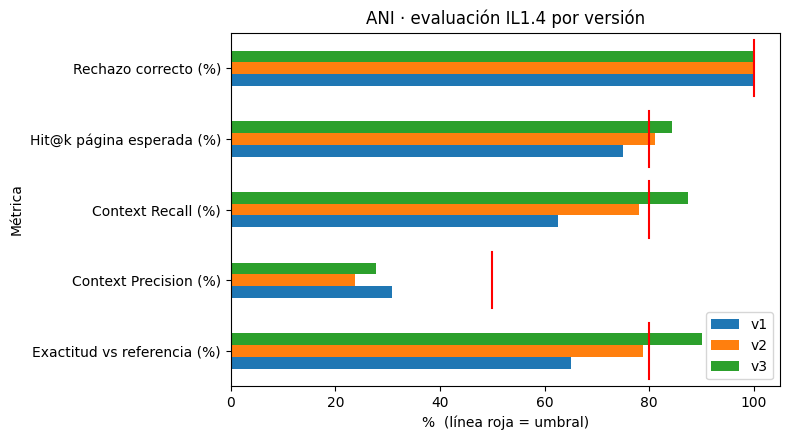


Guardado en Drive: ANI_evaluacion_IL14_v3.xlsx y ANI_evaluacion_IL14.png


In [22]:
# ============================================================
# PASO 20 · Juez IL1.4 sobre la versión v3 + comparación v1 vs v2 vs v3
#   Mismo código del Paso 16, con VERSION = "v3" y un ajuste: al reconstruir el contexto,
#   se usa también la pregunta original (multi-consulta), igual que lo vio el agente.
#   Los puntajes del reranker quedaron guardados en memoria del Paso 19, así que no debería tardar mucho.
# Gasta 1 consulta por pregunta (40). Si se corta, vuelve a ejecutar: retoma donde quedó.
# ============================================================

import os, re, json, time, glob
import pandas as pd
import matplotlib.pyplot as plt

VERSION = "v3"                              # multi-consulta + reranker + reglas 11-13
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"
JUECES = ["gemini-flash-latest", "gemini-3.5-flash", "gemini-3.1-flash-lite"]  # distinto al que responde, si hay cuota
PAUSA = 4
MAX_CHARS = 4000                              # por fragmento, para no reventar el contexto del juez

# Umbrales para decir "funciona" (definidos por el equipo; el curso no fija valores)
UMBRALES = {
    "Exactitud vs referencia (%)": 80,
    "Fidelidad promedio (/10)": 8,
    "Relevancia promedio (/10)": 8,
    "Context Precision (%)": 50,
    "Context Recall (%)": 80,
    "Hit@k página esperada (%)": 80,
    "Rechazo correcto (%)": 100,
}

# ---------- 1. Cargar preguntas y respuestas del Paso 19 ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
df = pd.read_excel(sorted(candidatos)[-1], sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
resp = json.load(open(os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json"), encoding="utf-8"))
print(f"{len(df)} preguntas · respuestas de ANI versión {VERSION}")

def paginas(texto):
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def doc_clave(texto):
    return [c for c in ("Evaluaci", "Convivencia", "Decreto") if c in str(texto)]

SINONIMO = {"evaluación": "evaluacion", "convivencia": "convivencia"}

# ---------- 2. Reconstruir el contexto que recuperó el agente ----------
# Los embeddings son locales (e5-small): re-buscar no gasta cuota de Gemini.
def contexto(fila, r):
    PREGUNTA_ACTUAL["texto"] = fila["pregunta"]      # v3: el buscador también usa la pregunta original
    frs = []
    consultas = r.get("consultas")
    if consultas:                                   # consultas reales del agente
        for c in consultas:
            if c["herramienta"] == "buscar_norma_interna":
                frs += buscar(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
            elif c["herramienta"] == "buscar_norma_externa":
                frs += buscar(c["consulta"], "externa", k=3)
    else:                                           # resultados antiguos: aproxima con la pregunta
        dom = SINONIMO.get(fila["dominio"])
        if "buscar_norma_interna" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "interna", k=4, dominio=dom)
        if "buscar_norma_externa" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "externa", k=3)
    PREGUNTA_ACTUAL["texto"] = ""
    vistos, unicos = set(), []
    for f in frs:
        clave = (f["documento"], f["ubicacion"], f["paginas"], f["texto"][:50])
        if clave not in vistos:
            vistos.add(clave); unicos.append(f)
    return unicos

def hit_pagina(frs, doc_esp, pag_esp):
    """¿Algún fragmento recuperado es del documento esperado y cubre la página (±1)?"""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pe = paginas(pag_esp)
    for f in frs:
        if any(c in f["documento"] for c in esperado):
            if not pe or any(abs(p - q) <= 1 for p in paginas(f["paginas"]) for q in pe):
                return True
    return False

# ---------- 3. El juez ----------
PROMPT_JUEZ = """Eres un evaluador estricto de un sistema RAG que responde dudas de apoderados sobre reglamentos escolares.

PREGUNTA: {pregunta}

RESPUESTA DE REFERENCIA (correcta): {referencia}

FRAGMENTOS RECUPERADOS:
{fragmentos}

RESPUESTA DEL SISTEMA:
{respuesta}

Evalúa y responde SOLO con un JSON con estas claves:
- "fidelidad": entero 1-10. ¿Todo lo que afirma la respuesta está respaldado por los FRAGMENTOS? (1-3 inventa o contradice, 4-6 parcialmente, 7-10 totalmente). Si la respuesta solo dice que no está regulado, evalúa si eso es coherente con los fragmentos.
- "relevancia": entero 1-10. ¿Responde de forma directa y útil lo que preguntó el apoderado?
- "exactitud": "CORRECTO", "PARCIAL" o "INCORRECTO" comparando con la RESPUESTA DE REFERENCIA (no exijas coincidencia literal; un plazo, número o responsable distinto es INCORRECTO).
- "fragmentos_relevantes": lista con los números de los fragmentos útiles para responder (ej: [1, 3]); [] si ninguno.
- "contexto_suficiente": true si los fragmentos contienen la información de la referencia, false si no.
- "comentario": una frase con el problema principal, o "" si no hay."""

def juzgar(fila, r, frs):
    fragmentos = "\n\n".join(f"[F{i+1}] {f['documento']} | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto'][:MAX_CHARS]}"
                             for i, f in enumerate(frs)) or "(ninguno: el agente no buscó)"
    prompt = PROMPT_JUEZ.format(pregunta=fila["pregunta"], referencia=fila["resp_esperada"],
                                fragmentos=fragmentos, respuesta=r["respuesta"])
    cfg = types.GenerateContentConfig(temperature=0, response_mime_type="application/json")
    for modelo in JUECES:
        for intento in range(3):
            try:
                out = client.models.generate_content(model=modelo, contents=prompt, config=cfg)
                datos = json.loads(re.sub(r"```json|```", "", out.text).strip())
                datos["juez"] = modelo
                return datos
            except Exception as e:
                error = str(e)
                if "PerDay" in error:
                    break
                if any(x in error for x in ("429", "503", "UNAVAILABLE")):
                    time.sleep(10 * (intento + 1)); continue
                if isinstance(e, json.JSONDecodeError):
                    continue
                raise
    return None

# ---------- 4. Correr el juez (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_juez_IL14{SUFIJO}.json")
juicios = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}
fallos = 0
for _, fila in df.iterrows():
    k = str(int(fila["n"]))
    if k in juicios:
        continue
    if fallos >= 3:
        print("⛔ El juez se quedó sin cuota. Vuelve a ejecutar más tarde (retoma desde aquí)."); break
    r = resp[k]
    frs = contexto(fila, r)
    j = juzgar(fila, r, frs)
    if j is None:
        fallos += 1; continue
    fallos = 0
    j["n_fragmentos"] = len(frs)
    j["hit_pagina"] = hit_pagina(frs, fila["doc_esperado"], fila["pagina"])
    juicios[k] = j
    json.dump(juicios, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{k:>2}/{len(df)}] {j['exactitud']:<10} fid {j['fidelidad']:>2} · rel {j['relevancia']:>2} · {j['juez']}")
    time.sleep(PAUSA)

faltan = [str(int(n)) for n in df["n"] if str(int(n)) not in juicios]
if faltan:
    raise RuntimeError(f"Faltan {len(faltan)} juicios ({', '.join(faltan)}). Vuelve a ejecutar cuando haya cuota.")

# ---------- 5. Métricas IL1.4 ----------
filas = []
for _, fila in df.iterrows():
    k = str(int(fila["n"])); j = juicios[k]; r = resp[k]
    rechazo = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    nfr = j["n_fragmentos"]
    prec = (len(set(j["fragmentos_relevantes"]) & set(range(1, nfr + 1))) / nfr) if (nfr and not rechazo) else None
    exact = {"CORRECTO": 1, "PARCIAL": 0.5, "INCORRECTO": 0}.get(str(j["exactitud"]).upper(), 0)
    # Diagnóstico IL1.4: ¿falla el recuperador o el generador?
    if exact == 1 and j["fidelidad"] >= 7:
        diag = "OK"
    elif rechazo:
        diag = "rechazo mal resuelto"
    elif not j["contexto_suficiente"]:
        diag = "falla de RECUPERACIÓN (el dato no llegó)"
    elif j["fidelidad"] < 7:
        diag = "falla de GENERACIÓN (alucina)"
    else:
        diag = "falla de GENERACIÓN (tenía el dato y no lo usó)"
    filas.append({"n": int(fila["n"]), "pregunta": fila["pregunta"], "capacidad": fila["capacidad"],
                  "respuesta_esperada": fila["resp_esperada"], "respuesta_ANI": r["respuesta"],
                  "exactitud": j["exactitud"], "exactitud_num": exact, "fidelidad": j["fidelidad"],
                  "relevancia": j["relevancia"], "context_precision": prec,
                  "context_recall": None if rechazo else bool(j["contexto_suficiente"]),
                  "hit_pagina": None if rechazo else bool(j["hit_pagina"]),
                  "rechazo_ok": ("no está regulado" in r["respuesta"].lower()) if rechazo else None,
                  "segundos": r["segundos"], "diagnostico": diag, "comentario_juez": j.get("comentario", ""),
                  "juez": j["juez"]})
res = pd.DataFrame(filas)
nr = res[res["context_recall"].notna()]

valores = {
    "Exactitud vs referencia (%)": res["exactitud_num"].mean() * 100,
    "Fidelidad promedio (/10)": res["fidelidad"].mean(),
    "Relevancia promedio (/10)": res["relevancia"].mean(),
    "Context Precision (%)": nr["context_precision"].astype(float).mean() * 100,
    "Context Recall (%)": nr["context_recall"].astype(bool).mean() * 100,
    "Hit@k página esperada (%)": nr["hit_pagina"].astype(bool).mean() * 100,
    "Rechazo correcto (%)": res["rechazo_ok"].dropna().astype(bool).mean() * 100,
}
metricas = pd.DataFrame([{"Métrica": m, "Valor": round(v, 1), "Umbral": UMBRALES[m],
                          "¿Cumple?": "✅" if v >= UMBRALES[m] else "❌"} for m, v in valores.items()])
metricas.loc[len(metricas)] = ["Latencia mediana (s)", round(res["segundos"].median(), 1), "—", "—"]
print(f"\n=== Evaluación IL1.4 · versión {VERSION} ===")
print(metricas.to_string(index=False))

cumple = (metricas["¿Cumple?"] == "✅").sum(); total = len(UMBRALES)
print(f"\nVeredicto: {cumple}/{total} criterios cumplidos →",
      "FUNCIONA" if cumple == total else "FUNCIONA PARCIALMENTE" if cumple >= total / 2 else "NO FUNCIONA AÚN")

print("\nDiagnóstico por componente (qué falla):")
print(res["diagnostico"].value_counts().to_string())
print("\nPreguntas con problemas:")
for _, f in res[res["diagnostico"] != "OK"].iterrows():
    print(f"  #{f['n']:>2} [{f['diagnostico']}] {f['pregunta']}\n       → {f['comentario_juez']}")
    print("       ANI dijo: " + f["respuesta_ANI"].replace("\n", " ")[:300] + "…")

# ---------- 6. Guardar + comparar versiones ----------
xlsx = os.path.join(CARPETA, f"ANI_evaluacion_IL14{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

comparacion = {}
for archivo in sorted(glob.glob(os.path.join(CARPETA, "ANI_evaluacion_IL14*.xlsx"))):
    m = re.search(r"IL14_?(v\d+)?\.xlsx$", archivo)
    ver = (m.group(1) if m and m.group(1) else "v1")
    tabla = pd.read_excel(archivo, sheet_name="Métricas").set_index("Métrica")["Valor"]
    comparacion[ver] = tabla
comp = pd.DataFrame(comparacion).loc[list(UMBRALES)]
if comp.shape[1] > 1:
    print("\nComparación entre versiones:")
    print(comp.to_string())

pct = [m for m in UMBRALES if "%" in m]
ax = comp.loc[pct].plot(kind="barh", figsize=(8, 4.5))
for i, m in enumerate(pct):
    ax.plot([UMBRALES[m]] * 2, [i - 0.4, i + 0.4], color="red", lw=1.5)
ax.set_xlim(0, 105); ax.set_xlabel("%  (línea roja = umbral)")
ax.set_title("ANI · evaluación IL1.4 por versión"); plt.tight_layout()
plt.savefig(os.path.join(CARPETA, "ANI_evaluacion_IL14.png"), dpi=200); plt.show()
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_evaluacion_IL14.png")

In [23]:
# ============================================================
# PASO 21 · Simulación de "corte dinámico" para subir Context Precision (sin gastar cuota)
#   Idea: el reranker ya le da un puntaje a cada fragmento. Si descartamos los de puntaje bajo,
#   el agente recibe menos fragmentos "de relleno" → sube la precisión.
#   Riesgo: descartar un fragmento que sí era útil → baja el recall.
#   Cómo se mide sin Gemini: el juez del Paso 20 ya marcó qué fragmentos eran útiles en cada pregunta.
#   Se simula cada corte y se cuenta cuántos útiles se conservan y cuántos de relleno se eliminan.
#   (Siempre se conserva el mejor fragmento de cada búsqueda, para que el agente nunca quede sin nada.)
# ============================================================
import numpy as np
import pandas as pd

def puntaje(q, fid):
    if (q, fid) not in _cache_ce:
        _cache_ce[(q, fid)] = float(RERANKER.predict([(q, f"{POR_ID[fid]['ubicacion']}. {POR_ID[fid]['texto']}")])[0])
    return _cache_ce[(q, fid)]

def contexto_con_puntajes(fila, r):
    """Mismo contexto (y mismo orden) que vio el juez en el Paso 20, pero con el puntaje del reranker."""
    PREGUNTA_ACTUAL["texto"] = fila["pregunta"]
    items = []
    for c in r.get("consultas", []):
        if c["herramienta"] == "buscar_norma_interna":
            frs = buscar(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
        else:
            frs = buscar(c["consulta"], "externa", k=3)
        qs = [c["consulta"]] + ([fila["pregunta"]] if fila["pregunta"].lower() != c["consulta"].lower() else [])
        for i, f in enumerate(frs):
            items.append((f, max(puntaje(q, f["id"]) for q in qs), i == 0))   # i == 0 → mejor de la búsqueda
    PREGUNTA_ACTUAL["texto"] = ""
    vistos, unicos = {}, []
    for f, p, protegido in items:
        clave = (f["documento"], f["ubicacion"], f["paginas"], f["texto"][:50])
        if clave not in vistos:
            vistos[clave] = len(unicos); unicos.append([f, p, protegido])
        else:                                            # repetido: se queda con el mejor puntaje
            u = unicos[vistos[clave]]; u[1] = max(u[1], p); u[2] = u[2] or protegido
    return unicos

# ---------- Datos: preguntas con respuesta (las de rechazo no cuentan para precision) ----------
casos_cp = []
for _, fila in df.iterrows():
    k = str(int(fila["n"]))
    if str(fila["rechazar"]).strip().lower() in ("sí", "si") or not resp[k].get("consultas"):
        continue
    ctx = contexto_con_puntajes(fila, resp[k])
    utiles = set(juicios[k]["fragmentos_relevantes"])              # posiciones 1..n marcadas por el juez
    casos_cp.append({"n": int(fila["n"]), "ctx": ctx, "utiles": utiles})
print(f"{len(casos_cp)} preguntas analizadas")

# ---------- Simular cortes ----------
def simular(umbral):
    precisiones, conserva_todo, conserva_alguno, cantidad = [], [], [], []
    for c in casos_cp:
        quedan = {i + 1 for i, (f, p, prot) in enumerate(c["ctx"]) if prot or p >= umbral}
        cantidad.append(len(quedan))
        precisiones.append(len(quedan & c["utiles"]) / len(quedan))
        if c["utiles"]:
            conserva_todo.append(c["utiles"] <= quedan)
            conserva_alguno.append(bool(c["utiles"] & quedan))
    return {"Corte (puntaje reranker)": "sin corte" if umbral == -np.inf else f"≥ {umbral}",
            "Fragmentos promedio": round(np.mean(cantidad), 1),
            "Context Precision (%)": round(100 * np.mean(precisiones), 1),
            "Conserva TODOS los útiles (%)": round(100 * np.mean(conserva_todo), 1),
            "Conserva al menos 1 útil (%)": round(100 * np.mean(conserva_alguno), 1)}

tabla_corte = pd.DataFrame([simular(u) for u in [-np.inf, -4, -2, 0, 2, 4, 6]])
print("\n", tabla_corte.to_string(index=False))
print("\nLectura: buscamos el corte con mayor precisión que conserve casi todos los fragmentos útiles.")

32 preguntas analizadas

 Corte (puntaje reranker)  Fragmentos promedio  Context Precision (%)  Conserva TODOS los útiles (%)  Conserva al menos 1 útil (%)
               sin corte                  7.6                   27.8                           87.5                          87.5
                    ≥ -4                  6.3                   33.6                           87.5                          87.5
                    ≥ -2                  4.2                   43.2                           68.8                          78.1
                     ≥ 0                  2.5                   42.8                           37.5                          59.4
                     ≥ 2                  1.8                   40.9                           15.6                          53.1
                     ≥ 4                  1.5                   37.5                            9.4                          46.9
                     ≥ 6                  1.4                   

In [26]:
# ============================================================
# PASO 22 · Interfaz final: colores del liceo, logos, fuentes desplegables,
#           preguntas por tema, 👍/👎 con comentario y todo en una sola pantalla
#   Requisito: subir logo_liceo.png y logo_slep.png a la carpeta ANI del Drive.
#   Los votos se guardan en ANI_feedback.csv (carpeta ANI) para que UTP los revise.
# ============================================================
import os, re, csv, base64, html
from datetime import datetime
from zoneinfo import ZoneInfo
import gradio as gr

AZUL, AZUL_OSCURO, VERDE, VERDE_CLARO = "#2B3F7C", "#1C2B57", "#5A8279", "#E8F1EE"
ARCHIVO_FB = os.path.join(CARPETA, "ANI_feedback.csv")
GRADIO_6 = int(gr.__version__.split(".")[0]) >= 6

# ---------- 1. Logos (si no están en Drive, la interfaz funciona igual sin ellos) ----------
def logo(nombre, alto):
    ruta = os.path.join(CARPETA, nombre)
    if not os.path.exists(ruta):
        return ""
    datos = base64.b64encode(open(ruta, "rb").read()).decode()
    return f'<img src="data:image/png;base64,{datos}" style="height:{alto}px">'

ENCABEZADO = f"""
<div id="ani-enc">
  {logo("logo_liceo.png", 54)}
  <div class="ani-tit">
    <div class="t1">ANI · Asistente Normativo Institucional</div>
    <div class="t2">Liceo Polivalente Guillermo Labarca Hubertson · Evaluación, promoción y convivencia escolar</div>
  </div>
  {logo("logo_slep.png", 46)}
</div>"""

# ---------- 2. Respuesta con las fuentes en un desplegable ----------
def formatear_respuesta(texto):
    lineas = texto.strip().splitlines()
    fuentes = [l.replace("📄", "").strip(" *-") for l in lineas if "Fuente" in l]
    cuerpo = "\n".join(l for l in lineas if "Fuente" not in l).strip()
    if not fuentes:
        return cuerpo
    lista = "<br>".join(html.escape(f) for f in fuentes)
    return (f"{cuerpo}\n\n<details><summary>📄 Ver fuentes ({len(fuentes)})</summary>"
            f"<div class='ani-fuentes'>{lista}</div></details>")

def texto_de(contenido):
    """Gradio 6 entrega el contenido como lista de partes; Gradio 5 como texto."""
    if isinstance(contenido, str):
        return contenido
    if isinstance(contenido, dict):
        return contenido.get("text", "")
    if isinstance(contenido, (list, tuple)):
        return " ".join(texto_de(c) for c in contenido)
    return str(contenido)

# ---------- 3. Registro de votos en Drive ----------
COLUMNAS = ["id", "fecha", "voto", "pregunta", "respuesta", "modelo", "comentario"]

def guardar_fb(fila):
    nuevo = not os.path.exists(ARCHIVO_FB)
    with open(ARCHIVO_FB, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=COLUMNAS)
        if nuevo:
            w.writeheader()
        w.writerow(fila)

def ahora():
    return datetime.now(ZoneInfo("America/Santiago")).strftime("%Y-%m-%d %H:%M:%S")

# ---------- 4. Lógica del chat ----------
def responder_ui(mensaje, historial, agente_sesion, registro):
    if agente_sesion is None:
        agente_sesion = AgenteANI()
    if not mensaje or not mensaje.strip():
        return "", historial, gr.update(), agente_sesion, registro
    seguro, ocultos = anonimizar(mensaje)
    texto, modelo = agente_sesion.preguntar(seguro)
    historial = (historial or []) + [{"role": "user", "content": seguro},
                                     {"role": "assistant", "content": formatear_respuesta(texto)}]
    registro = {**(registro or {}), len(historial) - 1: {"pregunta": seguro, "respuesta": texto, "modelo": modelo}}
    return "", historial, formatear_traza(modelo, ocultos), agente_sesion, registro

def votar(registro, datos: gr.LikeData):
    if datos.liked is None:                       # se quitó el voto
        return gr.update(visible=False), None
    gusto = datos.liked if isinstance(datos.liked, bool) else str(datos.liked).lower() in ("like", "true")
    i = datos.index[0] if isinstance(datos.index, (list, tuple)) else datos.index
    info = (registro or {}).get(i, {"pregunta": "", "respuesta": texto_de(datos.value), "modelo": ""})
    id_voto = f"{ahora()}#{i}"
    guardar_fb({"id": id_voto, "fecha": ahora(), "voto": "👍" if gusto else "👎", "comentario": "", **info})
    if gusto:
        gr.Info("¡Gracias por tu evaluación!")
        return gr.update(visible=False), None
    return gr.update(visible=True), {"id": id_voto, **info}

def enviar_comentario(comentario, pendiente):
    if pendiente and comentario.strip():
        guardar_fb({"id": pendiente["id"], "fecha": ahora(), "voto": "comentario", "comentario": comentario.strip(),
                    "pregunta": pendiente["pregunta"], "respuesta": pendiente["respuesta"], "modelo": pendiente["modelo"]})
        gr.Info("¡Gracias! Tu comentario ayuda a mejorar a ANI.")
    return "", gr.update(visible=False), None

def nueva_conversacion():
    return [], "Conversación reiniciada.", AgenteANI(), {}, gr.update(visible=False)

# ---------- 5. Textos de la columna derecha ----------
EJEMPLOS = {
    "Evaluación": ["¿Con qué nota se aprueba un ramo?",
                   "Mi hijo faltó a una prueba por enfermedad, ¿qué pasa?",
                   "¿En cuánto tiempo el profe tiene que entregar las notas?"],
    "Promoción": ["Mi hijo ha ido 150 de 180 días de clases. ¿Repite?",
                  "Reprobó Matemáticas y tiene promedio 4,6. ¿Pasa de curso?",
                  "Terminó Lenguaje con 3,95. ¿Se le sube a 4,0?"],
    "Convivencia": ["A mi hija la molestan todos los días, ¿qué hace el liceo?",
                    "¿Cuántos atrasos puede tener antes de que me citen?",
                    "¿Cuánto plazo tengo para apelar una medida?"],
}

INTRO = """**¿Qué es ANI?** Un asistente que responde dudas de apoderados y estudiantes sobre el
**Reglamento de Evaluación**, el **Reglamento de Convivencia** y el **Decreto 67** del MINEDUC.
Cada respuesta indica el documento y la página de donde sale. Evalúa las respuestas con 👍 o 👎 para ayudarnos a mejorar."""

# Fuerza el modo claro aunque el computador esté en modo oscuro
JS_CLARO = """() => { const u = new URL(window.location.href);
  if (u.searchParams.get('__theme') !== 'light') { u.searchParams.set('__theme', 'light'); window.location.replace(u.href); } }"""

# ---------- 6. Estilo: todo en una pantalla ----------
CSS = f"""
footer {{display: none !important;}}
.gradio-container {{max-width: 100% !important; padding: 0 18px !important; background: #F5F7FA;}}
.gradio-container > main, .gradio-container .main {{padding-top: 8px !important;}}
#ani-enc {{display: flex; align-items: center; gap: 16px; background: white; padding: 8px 18px;
          border-radius: 12px; border-bottom: 4px solid {VERDE}; box-shadow: 0 1px 4px rgba(0,0,0,.08);}}
#ani-enc .ani-tit {{flex: 1;}}
#ani-enc .t1 {{font-size: 22px; font-weight: 700; color: {AZUL_OSCURO};}}
#ani-enc .t2 {{font-size: 13px; color: {VERDE}; font-weight: 600;}}
#ani-chat {{flex-grow: 1; min-height: 0; background: white !important;}}
#ani-lateral {{max-height: calc(100vh - 135px); overflow-y: auto;}}
#ani-lateral h3 {{color: {AZUL_OSCURO}; margin: 4px 0;}}
.ani-ej {{text-align: left !important; justify-content: flex-start !important; font-size: 13px !important;
          background: {VERDE_CLARO} !important; color: {AZUL_OSCURO} !important; border: 1px solid #CFE0DA !important;}}
.ani-ej:hover {{background: {VERDE} !important; color: white !important;}}
#ani-aviso {{font-size: 11.5px; color: #6B7280; margin-top: -6px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis;}}
details summary {{cursor: pointer; color: {VERDE}; font-weight: 600;}}
.ani-fuentes {{font-size: 12.5px; color: #374151; background: {VERDE_CLARO}; padding: 6px 10px;
              border-radius: 8px; margin-top: 4px; border-left: 3px solid {VERDE};}}
#ani-intro {{background: white; border-left: 4px solid {VERDE}; border-radius: 10px; padding: 8px 12px;
             font-size: 12.5px; color: #374151;}}
#ani-com {{border: 1px solid #F3C9C9; background: #FFF7F7; border-radius: 10px;}}
"""

TEMA = gr.themes.Soft(primary_hue="blue", secondary_hue="green").set(
    button_primary_background_fill=AZUL, button_primary_background_fill_hover=AZUL_OSCURO,
    button_primary_text_color="white")

# ---------- 7. Interfaz ----------
try:
    demo.close()
except Exception:
    pass

extra_blocks = {} if GRADIO_6 else {"theme": TEMA, "css": CSS, "js": JS_CLARO}
with gr.Blocks(title="ANI · Asistente Normativo Institucional", fill_height=True, **extra_blocks) as demo:
    agente_sesion, registro, pendiente = gr.State(None), gr.State({}), gr.State(None)
    gr.HTML(ENCABEZADO)
    with gr.Row(equal_height=False, scale=1):
        with gr.Column(scale=13):
            chat_args = dict(label="Conversación", show_label=False, elem_id="ani-chat", height="calc(100vh - 235px)",
                             placeholder="<b>¡Hola!</b> Soy ANI. Pregúntame sobre evaluación, promoción o convivencia escolar.")
            chat = gr.Chatbot(**chat_args) if GRADIO_6 else gr.Chatbot(type="messages", **chat_args)
            with gr.Row():
                entrada = gr.Textbox(placeholder="Escribe tu consulta y presiona Enter…", show_label=False,
                                     scale=8, container=False)
                enviar = gr.Button("Enviar", variant="primary", scale=1, min_width=90)
                boton_nueva = gr.Button("Nueva", scale=1, min_width=90)
            gr.Markdown("ℹ️ Apoyo informativo, no reemplaza la decisión del liceo · No ingreses nombres, RUT ni datos personales",
                        elem_id="ani-aviso")
        with gr.Column(scale=6, elem_id="ani-lateral"):
            with gr.Group(visible=False, elem_id="ani-com") as caja_com:
                comentario = gr.Textbox(label="👎 ¿Qué estuvo mal? (opcional)", lines=2,
                                        placeholder="Ej: el plazo no es ese, faltó un requisito…")
                enviar_com = gr.Button("Enviar comentario", size="sm", variant="primary")
            gr.Markdown(INTRO, elem_id="ani-intro")
            gr.Markdown("### Preguntas frecuentes")
            botones = []
            with gr.Tabs():
                for tema, preguntas in EJEMPLOS.items():
                    with gr.Tab(tema):
                        for p in preguntas:
                            botones.append((gr.Button(p, size="sm", elem_classes="ani-ej"), p))
            with gr.Accordion("🔍 Trazabilidad (cómo respondió ANI)", open=False):
                panel = gr.Markdown("Aquí aparecerán las búsquedas, fragmentos y cálculos que use ANI.")

    entradas = [entrada, chat, agente_sesion, registro]
    salidas = [entrada, chat, panel, agente_sesion, registro]
    entrada.submit(responder_ui, entradas, salidas)
    enviar.click(responder_ui, entradas, salidas)
    for b, p in botones:
        b.click(lambda h, a, r, p=p: responder_ui(p, h, a, r), [chat, agente_sesion, registro], salidas)
    chat.like(votar, [registro], [caja_com, pendiente])
    enviar_com.click(enviar_comentario, [comentario, pendiente], [comentario, caja_com, pendiente])
    boton_nueva.click(nueva_conversacion, None, [chat, panel, agente_sesion, registro, caja_com])

extra_launch = {"theme": TEMA, "css": CSS, "js": JS_CLARO} if GRADIO_6 else {}
demo.launch(share=True, **extra_launch)

Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4bcdb584995837ecb5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
# ============================================================
# PASO 23 · Diagnóstico: ¿por qué falló "¿En cuánto tiempo el profe tiene que entregar las notas?"
#   No gasta cuota. Ejecutar justo después de hacer esa pregunta en la interfaz.
# ============================================================
print("Lo que buscó el agente en la última pregunta:")
for t in traza:
    if t["herramienta"].startswith("buscar"):
        print(f"\n🔎 {t['herramienta']} · dominio {t.get('dominio')} · «{t['consulta']}»")
        for ubic, pag, sim in t["resultados"]:
            print("     -", ubic, pag)

PREGUNTA_ACTUAL["texto"] = "¿En cuánto tiempo el profe tiene que entregar las notas?"
for t in traza:
    if t["herramienta"] == "buscar_norma_interna":
        frs = buscar(t["consulta"], "interna", k=4, dominio=t.get("dominio"))
        print(f"\n¿Llegó el dato de los 10 días con «{t['consulta']}»?",
              "✅ sí" if any("no exceda los 10" in f["texto"] for f in frs) else "❌ no")
PREGUNTA_ACTUAL["texto"] = ""

Lo que buscó el agente en la última pregunta:

🔎 buscar_norma_interna · dominio evaluacion · «plazo entrega calificaciones notas docentes»
     - Sección 12 CASOS DE PLAGIO O COPIA EN EVALUACIONES · Art. 13° pág. 23-24
     - Sección 2 NORMAS GENERALES · Art. 3° pág. 8-9
     - Sección 8 LINEAMIENTOS SOBRE LA CALIFICACIÓN · Art. 9° pág. 19-20
     - Sección 12 CASOS DE PLAGIO O COPIA EN EVALUACIONES · Art. 13° pág. 23-24
     - Protocolo 7: PROTOCOLO FRENTE A SITUACIONES DE VULNERACIÓN DE DERECHOS pág. 109-117
     - Protocolo 5: PROTOCOLO ESPECIAL DE EXPULSIÓN Y CANCELACIÓN DE LA MATRÍ pág. 96-98

¿Llegó el dato de los 10 días con «plazo entrega calificaciones notas docentes»? ❌ no


In [27]:
# ============================================================
# PASO 24 · Diagnóstico del caso "10 días hábiles" (sin gastar cuota)
#   ¿El dato quedó cerca (bastaría con más candidatos) o lejos (hay que volver a buscar con otras palabras)?
# ============================================================
q_agente = "plazo entrega calificaciones notas docentes"
original = "¿En cuánto tiempo el profe tiene que entregar las notas?"
objetivo = next(f["id"] for f in fragmentos if "no exceda los 10" in f["texto"])

# 1. ¿En qué lugar quedó el fragmento correcto antes del reranker?
orden, sims, rrf = _candidatos([q_agente, original], "interna", "evaluacion")
pos = orden.index(objetivo) + 1 if objetivo in orden else None
print(f"1) Lugar del fragmento de los 10 días entre los candidatos: {pos} de {len(orden)}  (hoy el reranker relee los 20 primeros)")

# 2. Si el reranker releyera 40 candidatos, ¿en qué lugar quedaría?
if pos:
    reordenados = _reordenar([q_agente, original], orden[:40])
    pos_r = reordenados.index(objetivo) + 1 if objetivo in reordenados else None
    print(f"2) Con 40 candidatos, después del reranker queda en el lugar: {pos_r}  (llega al agente si es 1-4)")

# 3. Si el agente volviera a buscar con otras palabras, ¿llegaría?
print("3) Segunda búsqueda con otras palabras:")
PREGUNTA_ACTUAL["texto"] = original
for q in ["plazo para informar y retroalimentar los resultados de las evaluaciones",
          "días hábiles para entregar resultados de evaluaciones a los estudiantes",
          "deberes del docente al evaluar plazo de retroalimentación"]:
    frs = buscar(q, "interna", k=4, dominio="evaluacion")
    print(f"   {'✅' if any(f['id'] == objetivo for f in frs) else '❌'} «{q}»")
PREGUNTA_ACTUAL["texto"] = ""

1) Lugar del fragmento de los 10 días entre los candidatos: 56 de 74  (hoy el reranker relee los 20 primeros)
2) Con 40 candidatos, después del reranker queda en el lugar: None  (llega al agente si es 1-4)
3) Segunda búsqueda con otras palabras:
   ✅ «plazo para informar y retroalimentar los resultados de las evaluaciones»
   ✅ «días hábiles para entregar resultados de evaluaciones a los estudiantes»
   ✅ «deberes del docente al evaluar plazo de retroalimentación»


In [28]:
# ============================================================
# PASO 25 · Re-búsqueda obligatoria antes de rechazar (la regla 8, ahora asegurada por código)
#   Diagnóstico del Paso 24: con "calificaciones notas" el dato de los 10 días queda en el lugar 56;
#   con el vocabulario del reglamento ("resultados de las evaluaciones", "retroalimentar") llega siempre.
#   Si el agente va a decir "no está regulado" habiendo buscado UNA sola vez, se le pide intentarlo de nuevo.
# ============================================================
import time

PISTA = ("[Instrucción interna: en un intento anterior concluiste que no estaba regulado. Antes de concluir eso, "
         "haz AL MENOS DOS búsquedas distintas con buscar_norma_interna usando el vocabulario formal de los reglamentos "
         "(ej: notas → calificaciones o resultados de las evaluaciones; profe → docente; entregar → informar o retroalimentar; "
         "castigo → medida formativa o sanción; faltar → inasistencia) y también en el otro dominio. "
         "Solo si después de eso no aparece, responde 'No está regulado en los documentos disponibles.']\n")

if not hasattr(AgenteANI, "_preguntar_v3"):
    AgenteANI._preguntar_v3 = AgenteANI.preguntar

def preguntar_v4(self, mensaje):
    historial_antes = list(self.historial)
    texto, modelo = AgenteANI._preguntar_v3(self, mensaje)
    busquedas = sum(t["herramienta"] == "buscar_norma_interna" for t in traza)
    if modelo and "no está regulado" in texto.lower() and busquedas < 2:
        traza_antes = list(traza)
        self.historial = historial_antes                 # se descarta el intento fallido
        PREGUNTA_ACTUAL["texto"] = mensaje
        texto, modelo = AgenteANI._preguntar_base(self, PISTA + mensaje)
        traza[:0] = traza_antes                          # la trazabilidad muestra los dos intentos
        print("   🔁 re-búsqueda forzada antes de rechazar")
    return texto, modelo

AgenteANI.preguntar = preguntar_v4

# ---------- Prueba: ¿encuentra los 10 días y sigue rechazando lo que debe rechazar? ----------
casos_10 = ["¿En cuánto tiempo el profe tiene que entregar las notas?",
            "¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?"]
casos_rechazo = df[df["rechazar"].astype(str).str.strip().str.lower().isin(["sí", "si"])]["pregunta"].tolist()

print("Debe responder 10 días hábiles:")
for p in casos_10:
    t, m = AgenteANI().preguntar(p)
    print(f" {'✅' if '10 días' in t else '❌'} {p}" + ("" if "10 días" in t else f"\n      → {t[:200]}"))
    time.sleep(4)

print("\nDebe seguir rechazando (fuera de alcance):")
for p in casos_rechazo:
    t, m = AgenteANI().preguntar(p)
    ok = "no está regulado" in t.lower()
    print(f" {'✅' if ok else '❌'} {p}" + ("" if ok else f"\n      → {t[:200]}"))
    time.sleep(4)

Debe responder 10 días hábiles:
⏱️ 43.4 s con gemini-3.1-flash-lite · búsquedas: True
 ❌ ¿En cuánto tiempo el profe tiene que entregar las notas?
      → El reglamento establece que los docentes deben entregar los resultados de las evaluaciones en un plazo predeterminado, el cual debe ser registrado en el libro de clases y en la plataforma KIMCHE. No s
⏱️ 1.8 s con gemini-3.1-flash-lite · búsquedas: True
 ✅ ¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?

Debe seguir rechazando (fuera de alcance):
⏱️ 47.4 s con gemini-3.1-flash-lite · búsquedas: True
⏱️ 16.4 s con gemini-3.1-flash-lite · búsquedas: True
   🔁 re-búsqueda forzada antes de rechazar
 ✅ ¿Cuándo son las vacaciones de invierno este año?
⏱️ 3.6 s con gemini-3.1-flash-lite · búsquedas: False
⏱️ 42.9 s con gemini-3.1-flash-lite · búsquedas: True
   🔁 re-búsqueda forzada antes de rechazar
 ✅ ¿Qué menú hay hoy en el casino?
⏱️ 1.5 s con gemini-3.1-flash-lite · búsquedas: False
⏱️ 22.6 s con gemini-3.1-flash-

In [29]:
# ============================================================
# PASO 26 · Re-búsqueda también ante respuestas "a medias"
#   En el Paso 25 el agente respondió "un plazo predeterminado… no se especifica" (sin la frase exacta
#   "no está regulado"), así que la re-búsqueda no se activó. Ahora se detectan también esas frases.
# ============================================================
import time

NO_ENCONTRADO = ("no está regulado", "no especifica", "no se especifica", "no establece", "no se establece",
                 "no indica", "no se indica", "no se menciona", "no encontré", "no contempla", "no detalla")

def preguntar_v4(self, mensaje):
    historial_antes = list(self.historial)
    texto, modelo = AgenteANI._preguntar_v3(self, mensaje)
    if modelo and any(f in texto.lower() for f in NO_ENCONTRADO):
        traza_antes = list(traza)
        self.historial = historial_antes                 # se descarta el intento incompleto
        PREGUNTA_ACTUAL["texto"] = mensaje
        texto, modelo = AgenteANI._preguntar_base(self, PISTA + mensaje)
        traza[:0] = traza_antes                          # la trazabilidad muestra los dos intentos
        print("   🔁 re-búsqueda forzada")
    return texto, modelo

AgenteANI.preguntar = preguntar_v4

pruebas = [("¿En cuánto tiempo el profe tiene que entregar las notas?", "10 días"),
           ("¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?", "10 días"),
           ("¿Pueden dejar a mi hijo sin recreo como castigo?", "recreo")]
for p, clave in pruebas:
    t, m = AgenteANI().preguntar(p)
    print(f" {'✅' if clave in t else '❌'} {p}\n      → {t[:250]}\n")
    time.sleep(4)

⏱️ 10.5 s con gemini-3.1-flash-lite · búsquedas: True
⏱️ 59.3 s con gemini-3.1-flash-lite · búsquedas: True
   🔁 re-búsqueda forzada
 ✅ ¿En cuánto tiempo el profe tiene que entregar las notas?
      → Los resultados de las evaluaciones deben ser informados y retroalimentados por el docente en un plazo oportuno que no exceda los 10 días hábiles, resguardando la pertinencia pedagógica del proceso.

📄 Fuente: Reglamento de Evaluación y Promoción 2026

⏱️ 27.1 s con gemini-3.1-flash-lite · búsquedas: False
⏱️ 70.5 s con gemini-3.1-flash-lite · búsquedas: True
⏱️ 22.8 s con gemini-3.1-flash-lite · búsquedas: True
   🔁 re-búsqueda forzada
 ✅ ¿En cuánto tiempo el profe tiene que entregar las notas de una prueba?
      → Los resultados de las evaluaciones deben ser informados y retroalimentados por el docente en un plazo oportuno que no exceda los 10 días hábiles, resguardando la pertinencia pedagógica del proceso.

📄 Fuente: Reglamento de Evaluación y Promoción 2026

⏱️ 27.6 s con gemini-3.1-